In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# 1. CARGA DE LA INFORMACIÓN

In [3]:
notas = pd.read_csv("notas.txt", engine="python", sep=None)

In [4]:
notas.shape

(2194612, 36)

In [5]:
notas.head()

,EMPLID,NIVEL ACADÉMICO,CICLO,ID_MATERIA,NRO_MATERIA,NOMBRE_MATERIA,COD_PROGRAMA,NIVEL_ACADÉMICO_CURSO,ESTADO_INSCRIP_ESTUD,DESC_ESTADO_INSCRIP_ESTUD,...,FIRST_GENERATION,DESPLAZADO_VICTIMA_CONFLICTO,NOMBRE_PROGRAMA,COHORTE,CONCATENADO,DESERTOR,GRADUADO,ACTIVO,Escuela,Estrato
0,1000166060,PREG,2561,121031,MU0499,RECITAL PROYECTO DE GRADO,83,PREG,E,Inscrito,...,1.0,NaN,Música,2021-1,1000166060083,0.0,0.0,1.0,Escuela de Artes y Humanidades,4.0
1,1000109890,PREG,2266,129738,PT0231,EMPRESARISMO 001,1,PREG,E,Inscrito,...,NaN,NaN,Administración de Negocios,2020-1,1000109890001,0.0,1.0,0.0,Escuela de Administración,3.0
2,1000136707,PREG,2561,129703,PT0207,VALIDACIÓN 001,1,PREG,E,Inscrito,...,1.0,NaN,Administración de Negocios,2019-2,1000136707001,0.0,0.0,1.0,Escuela de Administración,6.0
3,1000237090,PREG,2466,129703,PT0207,VALIDACIÓN 001,1,PREG,E,Inscrito,...,0.0,NaN,Administración de Negocios,2020-1,1000237090001,0.0,0.0,1.0,Escuela de Administración,5.0
4,1000207743,PREG,2261,112801,EC0200,TRABAJO DE GRADO,3,PREG,E,Inscrito,...,0.0,NaN,Economía,2016-1,1000207743003,0.0,1.0,0.0,"E.Finanzas, Economía, Gobierno",4.0


In [6]:
notas.dtypes

EMPLID                              int64
NIVEL ACADÉMICO                    object
CICLO                               int64
ID_MATERIA                          int64
NRO_MATERIA                        object
NOMBRE_MATERIA                     object
COD_PROGRAMA                        int64
NIVEL_ACADÉMICO_CURSO              object
ESTADO_INSCRIP_ESTUD               object
DESC_ESTADO_INSCRIP_ESTUD          object
MOTIVO_ESTADO_INSCRIP              object
DESC_MOTIVO_ESTADO_INSCRIP         object
ULT_ACCION_INSCRIPCION             object
ULT_MOTIVO_ACCION_INSCRIPCION      object
DESC_MOTIVO_ACCION_INSCRIPCION     object
SISTEMA_CALIFICACION               object
SEMESTRE                           object
TIPO_SEMESTRE                     float64
Semestre valor                      int64
NOTA                               object
CRÉDITOS                            int64
UMES                                int64
EMPLID_ANÓNIMO                      int64
DISCAPACIDAD                      

# 2. ANÁLISIS DE VALORES FALTANTES

In [7]:
def analizar_valores_faltantes(df):
    """
    Analiza y visualiza valores faltantes
    """
    print("\n" + "="*80)
    print("ANÁLISIS DE VALORES FALTANTES")
    print("="*80)
    
    # Calcular porcentajes de valores faltantes
    missing = pd.DataFrame({
        'Columna': df.columns,
        'Valores_Faltantes': df.isnull().sum(),
        'Porcentaje': (df.isnull().sum() / len(df) * 100).round(2)
    })
    missing = missing[missing['Valores_Faltantes'] > 0].sort_values('Porcentaje', ascending=False)
    
    if len(missing) > 0:
        print("\nColumnas con valores faltantes:")
        print(missing.to_string(index=False))
        
        # Visualización
        fig, ax = plt.subplots(figsize=(10, 6))
        missing_sorted = missing.sort_values('Porcentaje')
        ax.barh(missing_sorted['Columna'], missing_sorted['Porcentaje'])
        ax.set_xlabel('Porcentaje de Valores Faltantes (%)')
        ax.set_title('Valores Faltantes por Columna')
        plt.tight_layout()
        plt.show()
    else:
        print("\n¡No hay valores faltantes en el dataset!")


ANÁLISIS DE VALORES FALTANTES

Columnas con valores faltantes:
                       Columna  Valores_Faltantes  Porcentaje
                 TIPO_SEMESTRE            2194612      100.00
DESC_MOTIVO_ACCION_INSCRIPCION            2177011       99.20
 ULT_MOTIVO_ACCION_INSCRIPCION            2176626       99.18
                  DISCAPACIDAD            2164256       98.62
         First generation epik            1963072       89.45
  DESPLAZADO_VICTIMA_CONFLICTO            1689990       77.01
         First_generation ayre            1099770       50.11
              FIRST_GENERATION             934503       42.58
                       Estrato             630186       28.72
        ULT_ACCION_INSCRIPCION              42477        1.94
                      DESERTOR                327        0.01
                      GRADUADO                327        0.01
                        ACTIVO                327        0.01


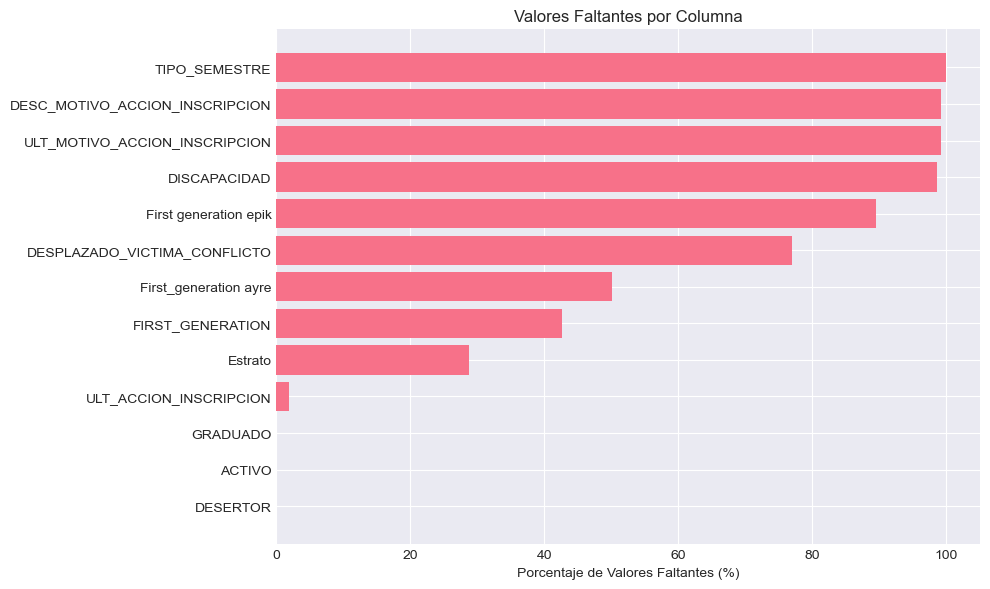

In [8]:
analizar_valores_faltantes(notas)

### 2.1 Limpieza y preparación del dataset para el análisis

### Aquí deberia hacerse la limpieza de los NAN?

In [9]:
notas.columns

Index(['EMPLID', 'NIVEL ACADÉMICO', 'CICLO', 'ID_MATERIA', 'NRO_MATERIA',
       'NOMBRE_MATERIA', 'COD_PROGRAMA', 'NIVEL_ACADÉMICO_CURSO',
       'ESTADO_INSCRIP_ESTUD', 'DESC_ESTADO_INSCRIP_ESTUD',
       'MOTIVO_ESTADO_INSCRIP', 'DESC_MOTIVO_ESTADO_INSCRIP',
       'ULT_ACCION_INSCRIPCION', 'ULT_MOTIVO_ACCION_INSCRIPCION',
       'DESC_MOTIVO_ACCION_INSCRIPCION', 'SISTEMA_CALIFICACION', 'SEMESTRE',
       'TIPO_SEMESTRE', 'Semestre valor', 'NOTA', 'CRÉDITOS', 'UMES',
       'EMPLID_ANÓNIMO', 'DISCAPACIDAD', 'First_generation ayre',
       'First generation epik', 'FIRST_GENERATION',
       'DESPLAZADO_VICTIMA_CONFLICTO', 'NOMBRE_PROGRAMA', 'COHORTE',
       'CONCATENADO', 'DESERTOR', 'GRADUADO', 'ACTIVO', 'Escuela', 'Estrato'],
      dtype='object')

In [10]:
notas = notas [[ 'EMPLID_ANÓNIMO','NIVEL ACADÉMICO','SEMESTRE', 'ID_MATERIA', 'NRO_MATERIA',
       'NOMBRE_MATERIA', 'COD_PROGRAMA', 'NOMBRE_PROGRAMA','Escuela','NIVEL_ACADÉMICO_CURSO',
       'SISTEMA_CALIFICACION', 'NOTA', 'CRÉDITOS',
        'DISCAPACIDAD', 'FIRST_GENERATION',
       'DESPLAZADO_VICTIMA_CONFLICTO', 'COHORTE', 'DESERTOR', 'GRADUADO', 'ACTIVO','Estrato']]

In [11]:
notas.columns = ['EMPLID_ANÓNIMO','NIVEL_ACADEMICO','SEMESTRE', 'ID_MATERIA', 'NRO_MATERIA',
       'NOMBRE_MATERIA', 'COD_PROGRAMA', 'NOMBRE_PROGRAMA','ESCUELA','NIVEL_ACADÉMICO_CURSO',
       'SISTEMA_CALIFICACION', 'NOTA', 'CRÉDITOS',
        'DISCAPACIDAD', 'FIRST_GENERATION',
       'DESPLAZADO_VICTIMA_CONFLICTO', 'COHORTE', 'DESERTOR', 'GRADUADO', 'ACTIVO','ESTRATO']

In [12]:
print("\nTipos de datos:")
print(notas.dtypes.sort_values())


Tipos de datos:
EMPLID_ANÓNIMO                    int64
ID_MATERIA                        int64
COD_PROGRAMA                      int64
CRÉDITOS                          int64
GRADUADO                        float64
DESERTOR                        float64
DESPLAZADO_VICTIMA_CONFLICTO    float64
FIRST_GENERATION                float64
ACTIVO                          float64
ESTRATO                         float64
ESCUELA                          object
NOTA                             object
NOMBRE_PROGRAMA                  object
DISCAPACIDAD                     object
NOMBRE_MATERIA                   object
NRO_MATERIA                      object
COHORTE                          object
SEMESTRE                         object
NIVEL_ACADEMICO                  object
NIVEL_ACADÉMICO_CURSO            object
SISTEMA_CALIFICACION             object
dtype: object


In [13]:
notas["NOTA"] = notas["NOTA"].astype("string").str.replace(",", ".", regex=False)

In [14]:
notas["EMPLID_ANÓNIMO"] = notas["EMPLID_ANÓNIMO"].astype('string')
notas["ID_MATERIA"] = notas["ID_MATERIA"].astype('string')
notas["COD_PROGRAMA"] = notas["COD_PROGRAMA"].astype('string')
notas["GRADUADO"] = notas["GRADUADO"].astype(bool)
notas["DESERTOR"] = notas["DESERTOR"].astype(bool)
notas["ACTIVO"] = notas["ACTIVO"].astype(bool)
notas["DESPLAZADO_VICTIMA_CONFLICTO"] = notas["DESPLAZADO_VICTIMA_CONFLICTO"].astype(bool)
notas["FIRST_GENERATION"] = notas["FIRST_GENERATION"].astype(bool)
notas["ESTRATO"] = notas["ESTRATO"].astype("Int64")
notas["ESTRATO"] = notas["ESTRATO"].astype('string')
notas["NOTA"] = notas["NOTA"].astype(float)

In [15]:
notas.dtypes

EMPLID_ANÓNIMO                  string[python]
NIVEL_ACADEMICO                         object
SEMESTRE                                object
ID_MATERIA                      string[python]
NRO_MATERIA                             object
NOMBRE_MATERIA                          object
COD_PROGRAMA                    string[python]
NOMBRE_PROGRAMA                         object
ESCUELA                                 object
NIVEL_ACADÉMICO_CURSO                   object
SISTEMA_CALIFICACION                    object
NOTA                                   float64
CRÉDITOS                                 int64
DISCAPACIDAD                            object
FIRST_GENERATION                          bool
DESPLAZADO_VICTIMA_CONFLICTO              bool
COHORTE                                 object
DESERTOR                                  bool
GRADUADO                                  bool
ACTIVO                                    bool
ESTRATO                         string[python]
dtype: object

# 3. ESTADÍSTICAS DESCRIPTIVAS

In [16]:
def estadisticas_descriptivas(df):
    """
    Genera estadísticas descriptivas del dataset
    """
    print("\n" + "="*80)
    print("ESTADÍSTICAS DESCRIPTIVAS")
    print("="*80)
    
    # Variables numéricas
    print("\n--- Variables Numéricas ---")
    print(df.describe())
    
    # Variables categóricas
    print("\n--- Variables Categóricas ---")
    cat_cols = df.select_dtypes(include=['object']).columns
    for col in cat_cols:
        print(f"\n{col}:")
        print(f"  Valores únicos: {df[col].nunique()}")
        print(f"  Distribución:")
        print(df[col].value_counts().head(10))

In [17]:
estadisticas_descriptivas(notas)


ESTADÍSTICAS DESCRIPTIVAS

--- Variables Numéricas ---
               NOTA      CRÉDITOS
count  2.194612e+06  2.194612e+06
mean   3.857949e+00  3.326536e+00
std    8.155144e-01  2.139776e+00
min    0.000000e+00  1.000000e+00
25%    3.400000e+00  3.000000e+00
50%    4.000000e+00  3.000000e+00
75%    4.400000e+00  3.000000e+00
max    5.000000e+00  2.400000e+01

--- Variables Categóricas ---

NIVEL_ACADEMICO:
  Valores únicos: 1
  Distribución:
NIVEL_ACADEMICO
PREG    2194612
Name: count, dtype: int64

SEMESTRE:
  Valores únicos: 52
  Distribución:
SEMESTRE
2018-1    52555
2019-1    52346
2017-1    52042
2016-1    51352
2020-1    50599
2018-2    50192
2017-2    49995
2025-1    49989
2016-2    48824
2019-2    48488
Name: count, dtype: int64

NRO_MATERIA:
  Valores únicos: 7700
  Distribución:
NRO_MATERIA
DE0084    23776
OG0591    23078
PR0312    14403
HL0591    13667
CO0133    13612
CO0135    13562
EC0101    12888
FI0116    12213
GP0039    11346
DE0119    11223
Name: count, dtype: int64



# 4. ANÁLISIS DE NOTAS

In [18]:
def analizar_notas(df):
    """
    Análisis detallado de las calificaciones
    """
    print("\n" + "="*80)
    print("ANÁLISIS DE CALIFICACIONES (NOTA)")
    print("="*80)
    
    print("\n--- Estadísticas de NOTA ---")
    print(df['NOTA'].describe())
    
    print(f"\nNota promedio general: {df['NOTA'].mean():.2f}")
    print(f"Mediana de notas: {df['NOTA'].median():.2f}")
    print(f"Desviación estándar: {df['NOTA'].std():.2f}")
    
    # Crear categorías de notas
    df['CATEGORIA_NOTA'] = pd.cut(df['NOTA'], 
                                   bins=[0, 2.5, 3.0, 3.5, 4.0, 5.0],
                                   labels=['Muy Bajo (0-2.5)', 'Bajo (2.5-3.0)', 
                                          'Medio (3.0-3.5)', 'Bueno (3.5-4.0)', 
                                          'Excelente (4.0-5.0)'])
    
    print("\n--- Distribución por Categoría ---")
    print(df['CATEGORIA_NOTA'].value_counts().sort_index())
    
    # Visualizaciones
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Histograma
    axes[0, 0].hist(df['NOTA'], bins=50, edgecolor='black', alpha=0.7)
    axes[0, 0].axvline(df['NOTA'].mean(), color='red', linestyle='--', label=f'Media: {df["NOTA"].mean():.2f}')
    axes[0, 0].axvline(df['NOTA'].median(), color='green', linestyle='--', label=f'Mediana: {df["NOTA"].median():.2f}')
    axes[0, 0].set_xlabel('Nota')
    axes[0, 0].set_ylabel('Frecuencia')
    axes[0, 0].set_title('Distribución de Notas')
    axes[0, 0].legend()
    
    # Boxplot
    axes[0, 1].boxplot(df['NOTA'].dropna())
    axes[0, 1].set_ylabel('Nota')
    axes[0, 1].set_title('Boxplot de Notas')
    
    # Notas por sistema de calificación
    df.groupby('SISTEMA_CALIFICACION')['NOTA'].mean().plot(kind='bar', ax=axes[1, 0])
    axes[1, 0].set_xlabel('Sistema de Calificación')
    axes[1, 0].set_ylabel('Nota Promedio')
    axes[1, 0].set_title('Nota Promedio por Sistema de Calificación')
    axes[1, 0].tick_params(axis='x', rotation=0)
    
    # Categorías de notas
    df['CATEGORIA_NOTA'].value_counts().sort_index().plot(kind='bar', ax=axes[1, 1])
    axes[1, 1].set_xlabel('Categoría')
    axes[1, 1].set_ylabel('Cantidad')
    axes[1, 1].set_title('Distribución por Categoría de Nota')
    axes[1, 1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Tasa de aprobación
    if 'SISTEMA_CALIFICACION' in df.columns:
        df['APROBADO'] = np.where(
            (df['SISTEMA_CALIFICACION'] == 'C30') & (df['NOTA'] >= 3.0), 'Sí',
            np.where((df['SISTEMA_CALIFICACION'] == 'C35') & (df['NOTA'] >= 3.5), 'Sí', 'No')
        )
        tasa_aprobacion = (df['APROBADO'] == 'Sí').sum() / len(df) * 100
        print(f"\nTasa de aprobación general: {tasa_aprobacion:.2f}%")



ANÁLISIS DE CALIFICACIONES (NOTA)

--- Estadísticas de NOTA ---
count    2.194612e+06
mean     3.857949e+00
std      8.155144e-01
min      0.000000e+00
25%      3.400000e+00
50%      4.000000e+00
75%      4.400000e+00
max      5.000000e+00
Name: NOTA, dtype: float64

Nota promedio general: 3.86
Mediana de notas: 4.00
Desviación estándar: 0.82

--- Distribución por Categoría ---
CATEGORIA_NOTA
Muy Bajo (0-2.5)        83848
Bajo (2.5-3.0)         173009
Medio (3.0-3.5)        396670
Bueno (3.5-4.0)        529545
Excelente (4.0-5.0)    996092
Name: count, dtype: int64


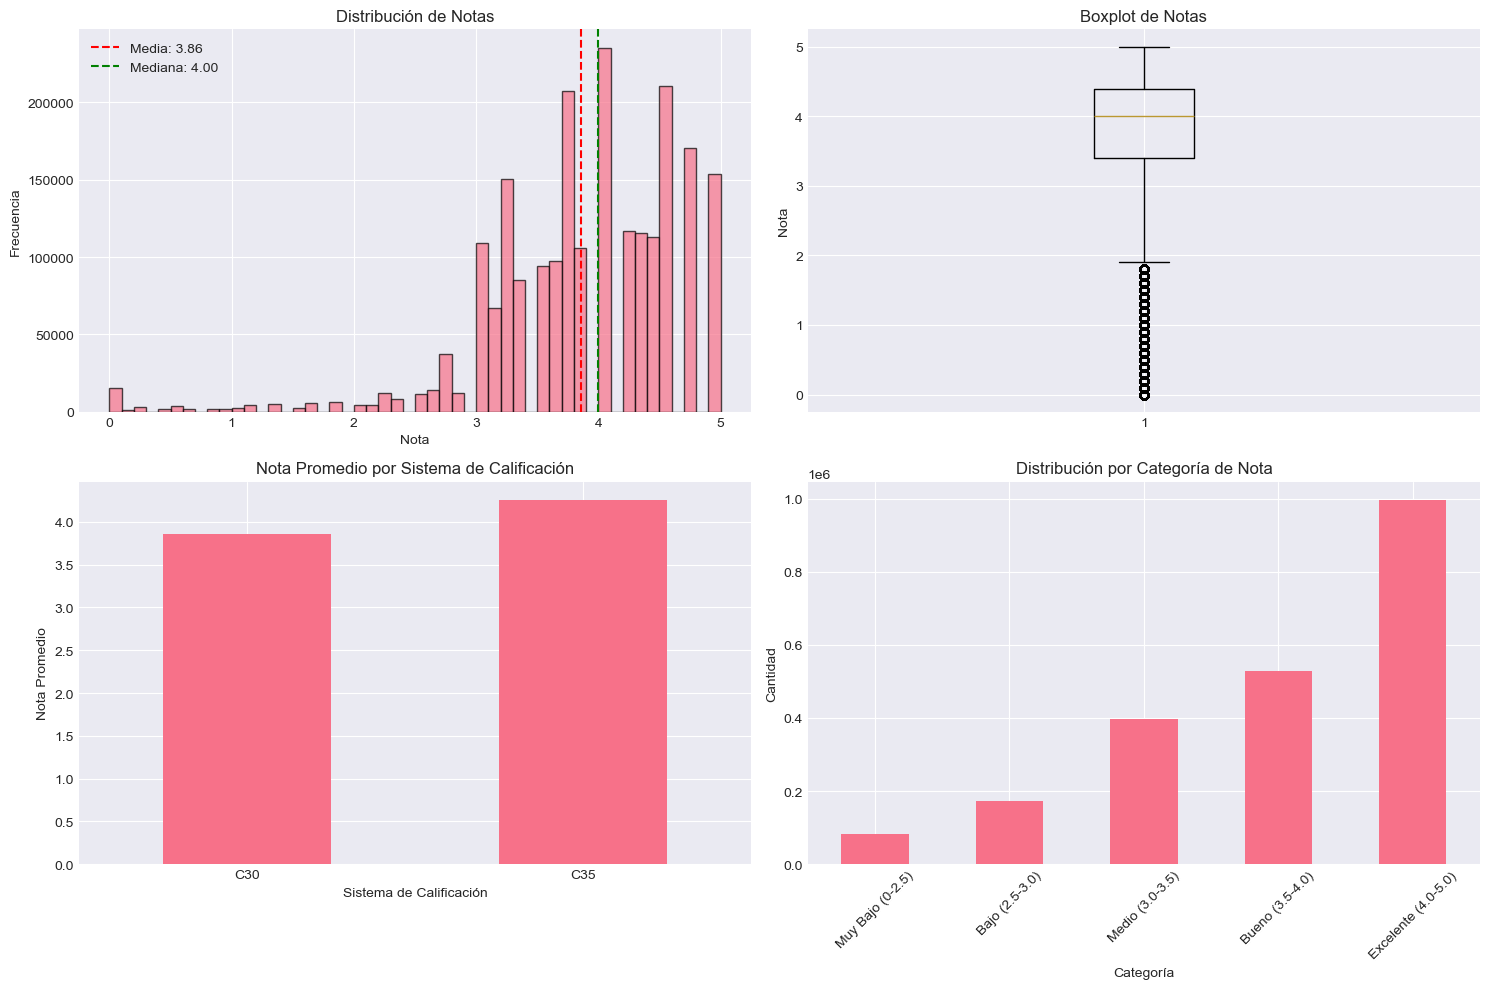


Tasa de aprobación general: 92.57%


In [19]:
analizar_notas(notas)

# 5. ANÁLISIS TEMPORAL

In [20]:
def analizar_temporal(df):
    """
    Análisis de la evolución temporal
    """
    print("\n" + "="*80)
    print("ANÁLISIS TEMPORAL")
    print("="*80)
    
    print(f"\nRango de semestres: {df['SEMESTRE'].min()} - {df['SEMESTRE'].max()}")
    print(f"Número de semestres únicos: {df['SEMESTRE'].nunique()}")
    
    # Evolución de notas por semestre
    notas_por_semestre = df.groupby('SEMESTRE')['NOTA'].agg(['mean', 'median', 'std']).reset_index()
    notas_por_semestre.columns = ['SEMESTRE', 'PROMEDIO', 'MEDIANA', 'DESV_STD']
    
    # Estudiantes únicos por semestre
    estudiantes_por_semestre = df.groupby('SEMESTRE')['EMPLID_ANÓNIMO'].nunique().reset_index()
    estudiantes_por_semestre.columns = ['SEMESTRE', 'ESTUDIANTES_UNICOS']
    
    # Materias únicas por semestre
    materias_por_semestre = df.groupby('SEMESTRE')['NRO_MATERIA'].nunique().reset_index()
    materias_por_semestre.columns = ['SEMESTRE', 'MATERIAS_UNICAS']
    
    # Número de registros por semestre
    registros_por_semestre = df.groupby('SEMESTRE').size().reset_index()
    registros_por_semestre.columns = ['SEMESTRE', 'REGISTROS']
    
    # Paso para las etiquetas (mostrar ~15 etiquetas)
    step = max(1, len(notas_por_semestre) // 15)
    
    # ========================================================================
    # GRÁFICA 1: Nota promedio y mediana por semestre con etiquetas
    # ========================================================================
    print("\n" + "-"*80)
    print("GRÁFICA 1: EVOLUCIÓN DE NOTAS POR SEMESTRE")
    print("-"*80)
    
    fig1, ax1 = plt.subplots(figsize=(16, 6))
    ax1.plot(notas_por_semestre['SEMESTRE'], notas_por_semestre['PROMEDIO'], 
             marker='o', label='Promedio', linewidth=2.5, markersize=5, color='#2E86AB')
    ax1.plot(notas_por_semestre['SEMESTRE'], notas_por_semestre['MEDIANA'], 
             marker='s', label='Mediana', linewidth=2.5, markersize=5, color='#A23B72')
    
    # Agregar etiquetas de datos
    for i in range(0, len(notas_por_semestre), step):
        ax1.annotate(f'{notas_por_semestre.iloc[i]["PROMEDIO"]:.2f}', 
                    (notas_por_semestre.iloc[i]['SEMESTRE'], notas_por_semestre.iloc[i]['PROMEDIO']),
                    textcoords="offset points", xytext=(0,8), ha='center', fontsize=8, 
                    color='#2E86AB', fontweight='bold')
    
    ax1.set_xlabel('Semestre', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Nota', fontsize=12, fontweight='bold')
    ax1.set_title('Evolución de Notas por Semestre', fontsize=14, fontweight='bold', pad=15)
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.tick_params(axis='x', rotation=45, labelsize=9)
    ax1.tick_params(axis='y', labelsize=10)
    plt.tight_layout()
    plt.show()
    
    # Tabla de datos
    print("\nTabla de Datos - Notas por Semestre:")
    tabla_notas = notas_por_semestre.copy()
    tabla_notas['PROMEDIO'] = tabla_notas['PROMEDIO'].round(2)
    tabla_notas['MEDIANA'] = tabla_notas['MEDIANA'].round(2)
    tabla_notas['DESV_STD'] = tabla_notas['DESV_STD'].round(2)
    print(tabla_notas.to_string(index=False))
    
    # ========================================================================
    # GRÁFICA 2: Estudiantes únicos por semestre
    # ========================================================================
    print("\n" + "-"*80)
    print("GRÁFICA 2: ESTUDIANTES ÚNICOS POR SEMESTRE")
    print("-"*80)
    
    fig2, ax2 = plt.subplots(figsize=(16, 6))
    ax2.plot(estudiantes_por_semestre['SEMESTRE'], estudiantes_por_semestre['ESTUDIANTES_UNICOS'],
             marker='o', color='#06A77D', linewidth=2.5, markersize=5)
    ax2.fill_between(estudiantes_por_semestre['SEMESTRE'], 
                     estudiantes_por_semestre['ESTUDIANTES_UNICOS'], 
                     alpha=0.3, color='#06A77D')
    
    # Agregar etiquetas de datos
    for i in range(0, len(estudiantes_por_semestre), step):
        ax2.annotate(f'{estudiantes_por_semestre.iloc[i]["ESTUDIANTES_UNICOS"]:,}', 
                    (estudiantes_por_semestre.iloc[i]['SEMESTRE'], 
                     estudiantes_por_semestre.iloc[i]['ESTUDIANTES_UNICOS']),
                    textcoords="offset points", xytext=(0,8), ha='center', fontsize=8,
                    color='#06A77D', fontweight='bold')
    
    ax2.set_xlabel('Semestre', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Número de Estudiantes Únicos', fontsize=12, fontweight='bold')
    ax2.set_title('Estudiantes Únicos por Semestre', fontsize=14, fontweight='bold', pad=15)
    ax2.grid(True, alpha=0.3, linestyle='--')
    ax2.tick_params(axis='x', rotation=45, labelsize=9)
    ax2.tick_params(axis='y', labelsize=10)
    plt.tight_layout()
    plt.show()
    
    # Tabla de datos
    print("\nTabla de Datos - Estudiantes Únicos por Semestre:")
    print(estudiantes_por_semestre.to_string(index=False))
    
    # ========================================================================
    # GRÁFICA 3: Materias únicas por semestre
    # ========================================================================
    print("\n" + "-"*80)
    print("GRÁFICA 3: MATERIAS ÚNICAS OFRECIDAS POR SEMESTRE")
    print("-"*80)
    
    fig3, ax3 = plt.subplots(figsize=(16, 6))
    ax3.plot(materias_por_semestre['SEMESTRE'], materias_por_semestre['MATERIAS_UNICAS'],
             marker='s', color='#9D4EDD', linewidth=2.5, markersize=5)
    ax3.fill_between(materias_por_semestre['SEMESTRE'], 
                     materias_por_semestre['MATERIAS_UNICAS'], 
                     alpha=0.3, color='#9D4EDD')
    
    # Agregar etiquetas de datos
    for i in range(0, len(materias_por_semestre), step):
        ax3.annotate(f'{materias_por_semestre.iloc[i]["MATERIAS_UNICAS"]:,}', 
                    (materias_por_semestre.iloc[i]['SEMESTRE'], 
                     materias_por_semestre.iloc[i]['MATERIAS_UNICAS']),
                    textcoords="offset points", xytext=(0,8), ha='center', fontsize=8,
                    color='#9D4EDD', fontweight='bold')
    
    ax3.set_xlabel('Semestre', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Número de Materias Únicas', fontsize=12, fontweight='bold')
    ax3.set_title('Materias Únicas Ofrecidas por Semestre', fontsize=14, fontweight='bold', pad=15)
    ax3.grid(True, alpha=0.3, linestyle='--')
    ax3.tick_params(axis='x', rotation=45, labelsize=9)
    ax3.tick_params(axis='y', labelsize=10)
    plt.tight_layout()
    plt.show()
    
    # Tabla de datos
    print("\nTabla de Datos - Materias Únicas por Semestre:")
    print(materias_por_semestre.to_string(index=False))
    
    # ========================================================================
    # GRÁFICA 4: Número de registros por semestre
    # ========================================================================
    print("\n" + "-"*80)
    print("GRÁFICA 4: TOTAL DE REGISTROS POR SEMESTRE")
    print("-"*80)
    
    fig4, ax4 = plt.subplots(figsize=(16, 6))
    ax4.bar(registros_por_semestre['SEMESTRE'], registros_por_semestre['REGISTROS'], 
            color='#F07167', alpha=0.8, edgecolor='darkred', linewidth=0.5)
    
    # Agregar etiquetas de datos
    for i in range(0, len(registros_por_semestre), step):
        ax4.text(registros_por_semestre.iloc[i]['SEMESTRE'], 
                registros_por_semestre.iloc[i]['REGISTROS'],
                f'{registros_por_semestre.iloc[i]["REGISTROS"]:,}',
                ha='center', va='bottom', fontsize=8, fontweight='bold', color='darkred')
    
    ax4.set_xlabel('Semestre', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Número de Registros', fontsize=12, fontweight='bold')
    ax4.set_title('Total de Registros por Semestre', fontsize=14, fontweight='bold', pad=15)
    ax4.tick_params(axis='x', rotation=45, labelsize=9)
    ax4.tick_params(axis='y', labelsize=10)
    ax4.grid(True, alpha=0.3, axis='y', linestyle='--')
    plt.tight_layout()
    plt.show()
    
    # Tabla de datos
    print("\nTabla de Datos - Registros por Semestre:")
    print(registros_por_semestre.to_string(index=False))
    
    # ========================================================================
    # ESTADÍSTICAS GENERALES
    # ========================================================================
    # Estadísticas por año
    df['AÑO'] = df['SEMESTRE'].astype(str).str[:4]
    print("\n" + "="*80)
    print("ESTADÍSTICAS GENERALES")
    print("="*80)
    print("\n--- Registros por Año ---")
    print(df['AÑO'].value_counts().sort_index())
    
    # Estadísticas adicionales
    print("\n--- Estadísticas por Semestre ---")
    print(f"Promedio de estudiantes únicos por semestre: {estudiantes_por_semestre['ESTUDIANTES_UNICOS'].mean():.0f}")
    print(f"Promedio de materias únicas por semestre: {materias_por_semestre['MATERIAS_UNICAS'].mean():.0f}")
    print(f"Promedio de registros por semestre: {registros_por_semestre['REGISTROS'].mean():.0f}")
    
    # Semestre con más estudiantes
    max_estudiantes = estudiantes_por_semestre.loc[estudiantes_por_semestre['ESTUDIANTES_UNICOS'].idxmax()]
    print(f"\nSemestre con más estudiantes: {max_estudiantes['SEMESTRE']} ({max_estudiantes['ESTUDIANTES_UNICOS']:,} estudiantes)")
    
    # Semestre con más materias
    max_materias = materias_por_semestre.loc[materias_por_semestre['MATERIAS_UNICAS'].idxmax()]
    print(f"Semestre con más materias ofrecidas: {max_materias['SEMESTRE']} ({max_materias['MATERIAS_UNICAS']:,} materias)")



ANÁLISIS TEMPORAL

Rango de semestres: 2000-1 - 2025-2
Número de semestres únicos: 52

--------------------------------------------------------------------------------
GRÁFICA 1: EVOLUCIÓN DE NOTAS POR SEMESTRE
--------------------------------------------------------------------------------


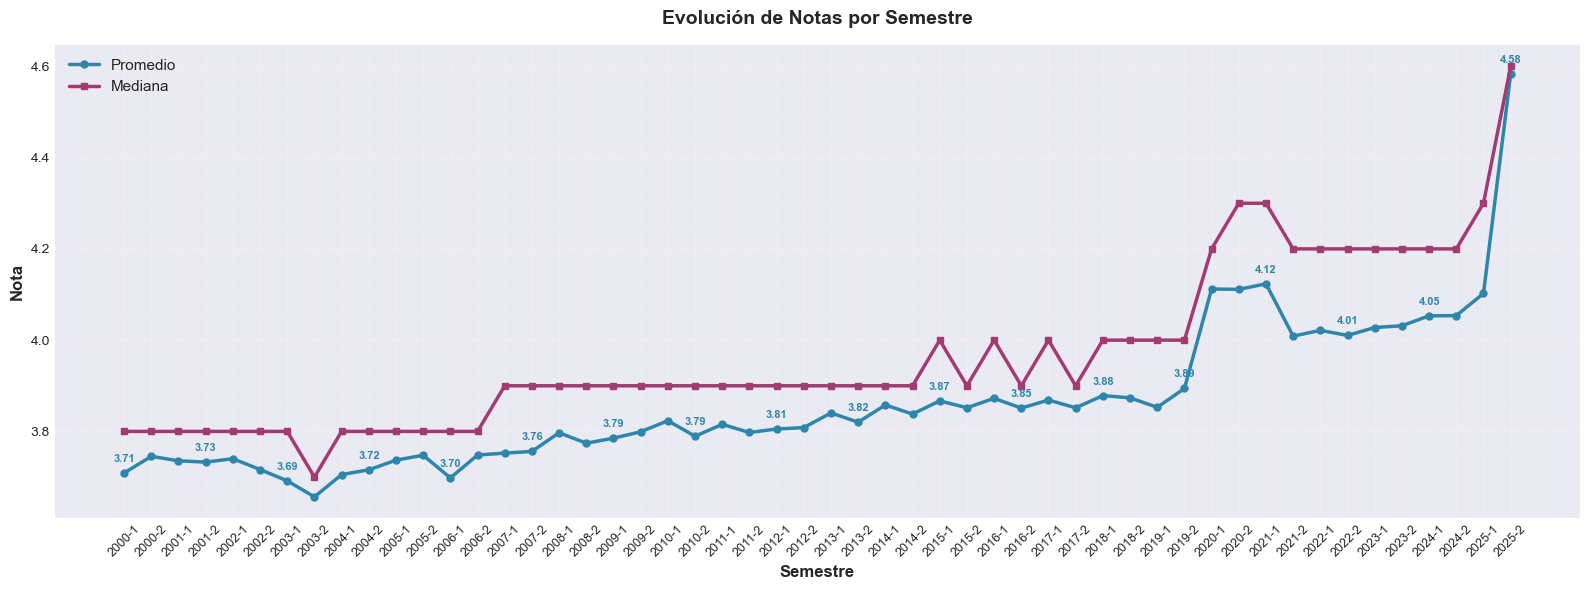


Tabla de Datos - Notas por Semestre:
SEMESTRE  PROMEDIO  MEDIANA  DESV_STD
  2000-1      3.71      3.8      0.78
  2000-2      3.75      3.8      0.77
  2001-1      3.74      3.8      0.75
  2001-2      3.73      3.8      0.77
  2002-1      3.74      3.8      0.78
  2002-2      3.72      3.8      0.76
  2003-1      3.69      3.8      0.78
  2003-2      3.66      3.7      0.78
  2004-1      3.71      3.8      0.80
  2004-2      3.72      3.8      0.74
  2005-1      3.74      3.8      0.79
  2005-2      3.75      3.8      0.77
  2006-1      3.70      3.8      0.89
  2006-2      3.75      3.8      0.81
  2007-1      3.75      3.9      0.83
  2007-2      3.76      3.9      0.81
  2008-1      3.80      3.9      0.83
  2008-2      3.77      3.9      0.83
  2009-1      3.79      3.9      0.83
  2009-2      3.80      3.9      0.80
  2010-1      3.82      3.9      0.79
  2010-2      3.79      3.9      0.81
  2011-1      3.82      3.9      0.79
  2011-2      3.80      3.9      0.81
  2012-1    

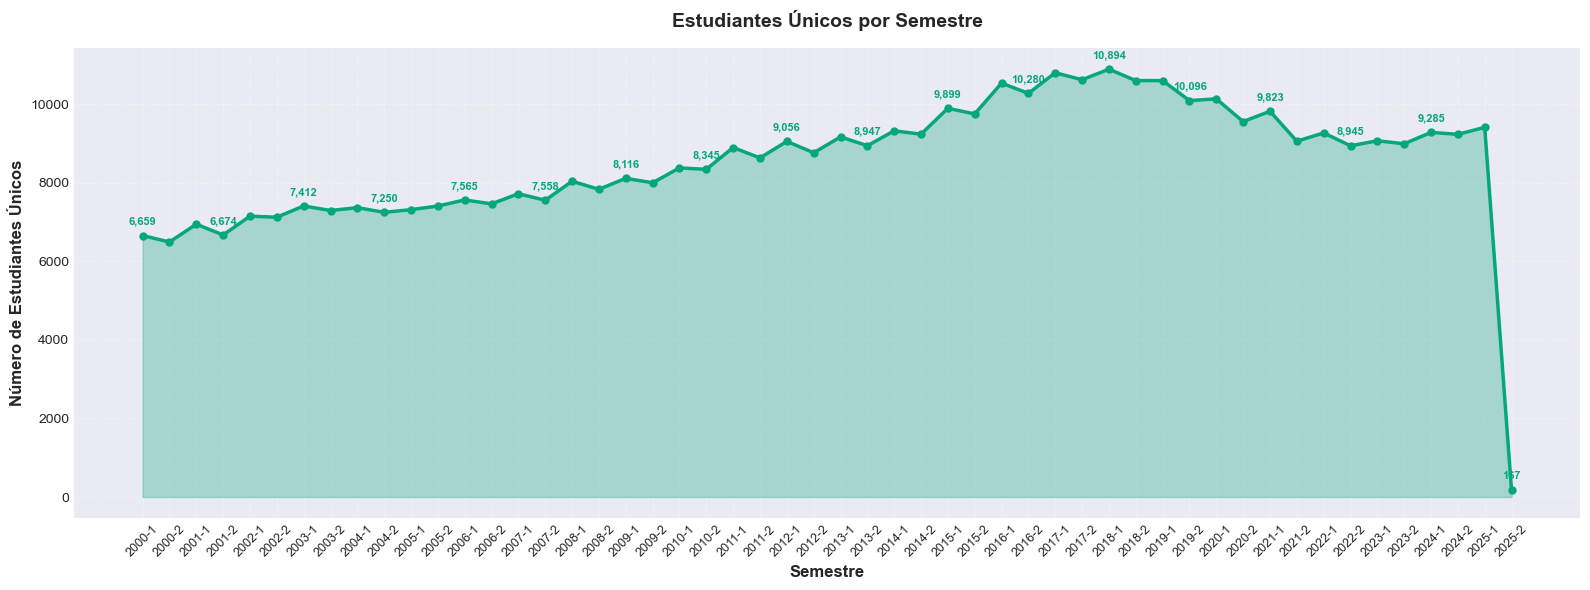


Tabla de Datos - Estudiantes Únicos por Semestre:
SEMESTRE  ESTUDIANTES_UNICOS
  2000-1                6659
  2000-2                6494
  2001-1                6948
  2001-2                6674
  2002-1                7152
  2002-2                7126
  2003-1                7412
  2003-2                7296
  2004-1                7368
  2004-2                7250
  2005-1                7318
  2005-2                7411
  2006-1                7565
  2006-2                7466
  2007-1                7723
  2007-2                7558
  2008-1                8041
  2008-2                7836
  2009-1                8116
  2009-2                8002
  2010-1                8381
  2010-2                8345
  2011-1                8900
  2011-2                8636
  2012-1                9056
  2012-2                8767
  2013-1                9170
  2013-2                8947
  2014-1                9325
  2014-2                9240
  2015-1                9899
  2015-2             

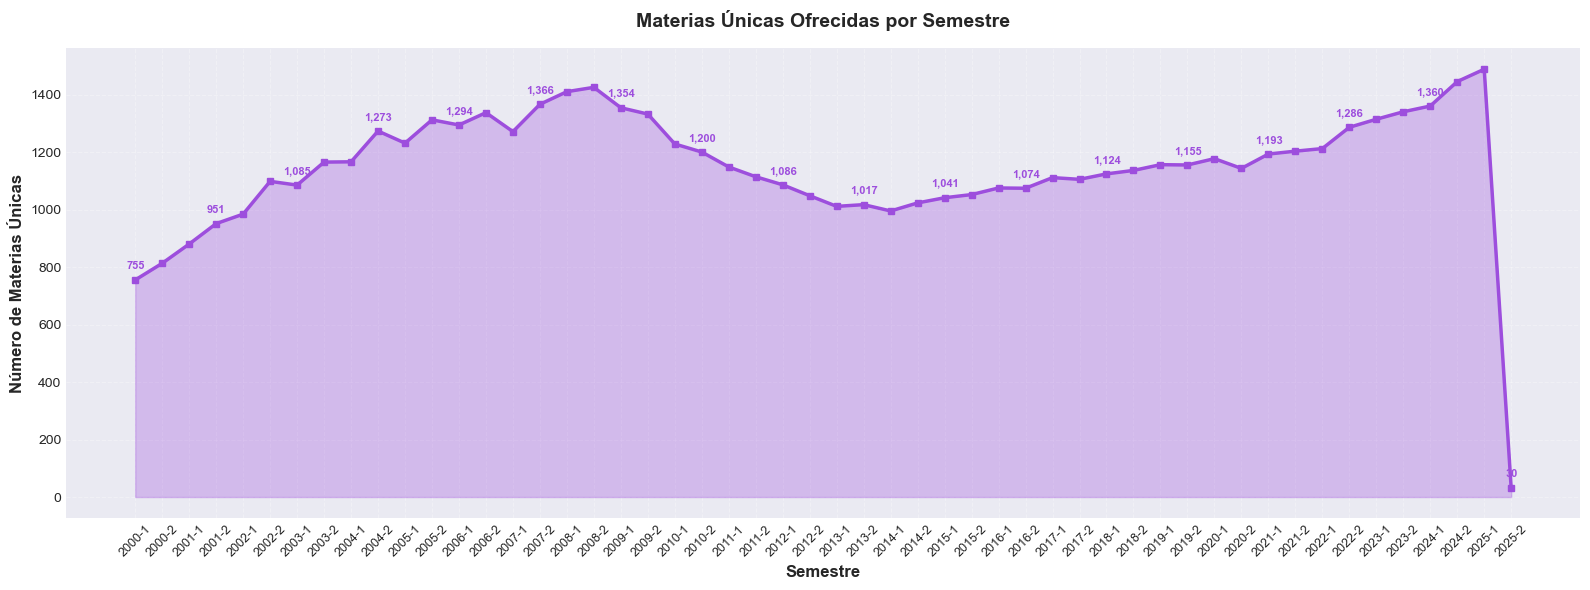


Tabla de Datos - Materias Únicas por Semestre:
SEMESTRE  MATERIAS_UNICAS
  2000-1              755
  2000-2              813
  2001-1              880
  2001-2              951
  2002-1              984
  2002-2             1098
  2003-1             1085
  2003-2             1165
  2004-1             1166
  2004-2             1273
  2005-1             1231
  2005-2             1312
  2006-1             1294
  2006-2             1337
  2007-1             1271
  2007-2             1366
  2008-1             1410
  2008-2             1425
  2009-1             1354
  2009-2             1332
  2010-1             1228
  2010-2             1200
  2011-1             1148
  2011-2             1114
  2012-1             1086
  2012-2             1048
  2013-1             1011
  2013-2             1017
  2014-1              995
  2014-2             1023
  2015-1             1041
  2015-2             1052
  2016-1             1075
  2016-2             1074
  2017-1             1111
  2017-2        

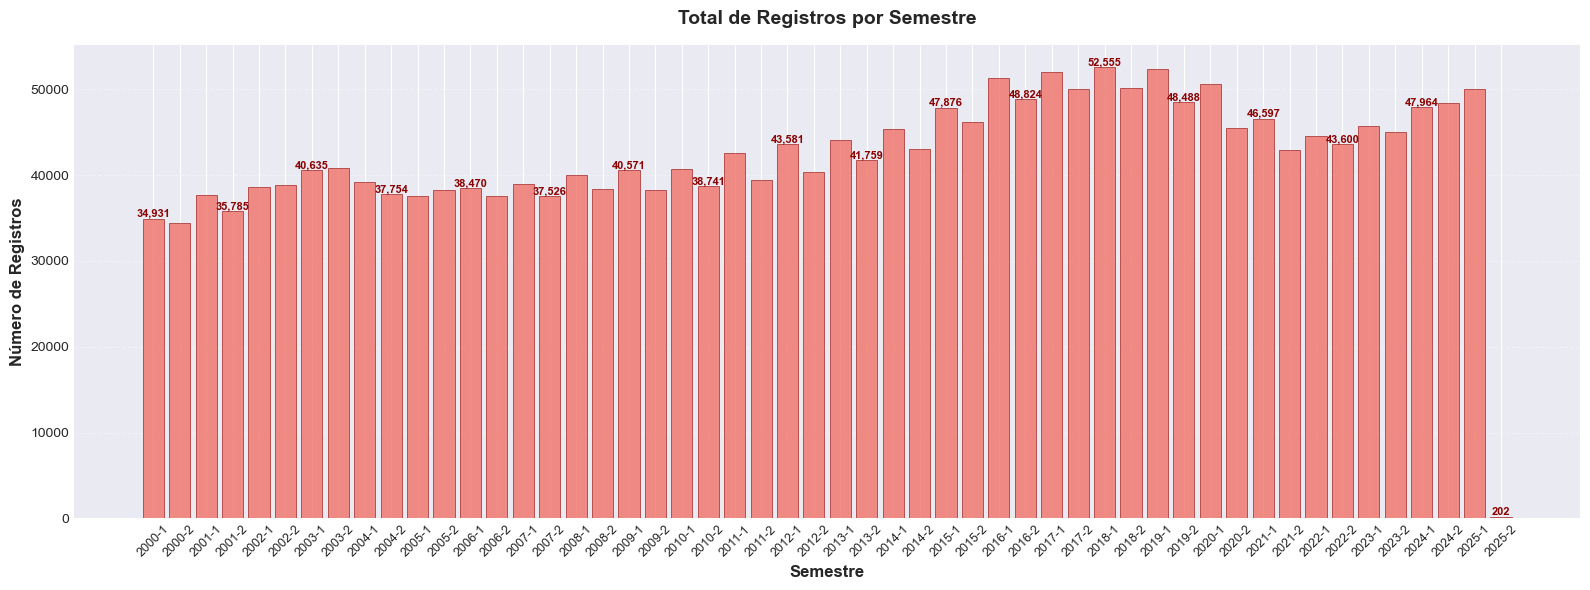


Tabla de Datos - Registros por Semestre:
SEMESTRE  REGISTROS
  2000-1      34931
  2000-2      34374
  2001-1      37661
  2001-2      35785
  2002-1      38567
  2002-2      38880
  2003-1      40635
  2003-2      40845
  2004-1      39213
  2004-2      37754
  2005-1      37544
  2005-2      38243
  2006-1      38470
  2006-2      37579
  2007-1      38996
  2007-2      37526
  2008-1      40013
  2008-2      38335
  2009-1      40571
  2009-2      38216
  2010-1      40660
  2010-2      38741
  2011-1      42536
  2011-2      39399
  2012-1      43581
  2012-2      40361
  2013-1      44083
  2013-2      41759
  2014-1      45356
  2014-2      43067
  2015-1      47876
  2015-2      46208
  2016-1      51352
  2016-2      48824
  2017-1      52042
  2017-2      49995
  2018-1      52555
  2018-2      50192
  2019-1      52346
  2019-2      48488
  2020-1      50599
  2020-2      45447
  2021-1      46597
  2021-2      42926
  2022-1      44596
  2022-2      43600
  2023-1      4567

In [21]:
analizar_temporal(notas)

# 6. ANÁLISIS POR ESCUELAS Y PROGRAMAS

In [22]:
def analizar_escuelas_programas(df):
    """
    Análisis por escuelas y programas académicos
    """
    print("\n" + "="*80)
    print("ANÁLISIS POR ESCUELAS Y PROGRAMAS")
    print("="*80)
    
    # Análisis por escuela
    print("\n--- Distribución por ESCUELA ---")
    estudiantes_por_escuela = df.groupby('ESCUELA')['EMPLID_ANÓNIMO'].nunique()
    print(estudiantes_por_escuela)
    
    notas_por_escuela = df.groupby('ESCUELA').agg({
        'NOTA': ['mean', 'median'],
        'EMPLID_ANÓNIMO': 'nunique'
    }).round(2)
    notas_por_escuela.columns = ['mean', 'median', 'estudiantes']
    notas_por_escuela = notas_por_escuela.sort_values('mean', ascending=False)
    print("\n--- Estadísticas de Notas por ESCUELA ---")
    print(notas_por_escuela)
    
    # Visualizaciones
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Notas promedio por escuela
    notas_por_escuela['mean'].plot(kind='barh', ax=axes[0, 0], color='skyblue')
    axes[0, 0].set_xlabel('Nota Promedio')
    axes[0, 0].set_title('Nota Promedio por ESCUELA')
    
    # Distribución de estudiantes únicos por escuela
    estudiantes_por_escuela.plot(kind='pie', ax=axes[0, 1], autopct='%1.1f%%')
    axes[0, 1].set_title('Distribución de Estudiantes Únicos por ESCUELA')
    axes[0, 1].set_ylabel('')
    
    # Top 10 programas con más estudiantes únicos
    top_programas = df.groupby('NOMBRE_PROGRAMA')['EMPLID_ANÓNIMO'].nunique().nlargest(10)
    top_programas.plot(kind='barh', ax=axes[1, 0], color='mediumseagreen')
    axes[1, 0].set_xlabel('Número de Estudiantes Únicos')
    axes[1, 0].set_title('Top 10 Programas con Más Estudiantes Únicos')
    
    # Boxplot de notas por escuela
    df.boxplot(column='NOTA', by='ESCUELA', ax=axes[1, 1])
    axes[1, 1].set_xlabel('ESCUELA')
    axes[1, 1].set_ylabel('Nota')
    axes[1, 1].set_title('Distribución de Notas por ESCUELA')
    plt.suptitle('')
    
    plt.tight_layout()
    plt.show()
    
    # Top y bottom 10 programas por nota promedio
    notas_por_programa = df.groupby('NOMBRE_PROGRAMA').agg({
        'NOTA': 'mean',
        'EMPLID_ANÓNIMO': 'nunique'
    })
    notas_por_programa.columns = ['mean', 'estudiantes']
    notas_por_programa = notas_por_programa[notas_por_programa['estudiantes'] >= 50]  # Filtrar programas con al menos 50 estudiantes
    
    print("\n--- Top 10 Programas con Mejor Nota Promedio (mínimo 50 estudiantes) ---")
    print(notas_por_programa.nlargest(10, 'mean').round(2))
    
    print("\n--- Top 10 Programas con Menor Nota Promedio (mínimo 50 estudiantes) ---")
    print(notas_por_programa.nsmallest(10, 'mean').round(2))


ANÁLISIS POR ESCUELAS Y PROGRAMAS

--- Distribución por ESCUELA ---
ESCUELA
E Ciencias Aplic e Ingeniería     21826
E.Finanzas, Economía, Gobierno     4512
Escuela de Administración         26579
Escuela de Artes y Humanidades     5110
Escuela de Derecho                 3633
Name: EMPLID_ANÓNIMO, dtype: int64

--- Estadísticas de Notas por ESCUELA ---
                                mean  median  estudiantes
ESCUELA                                                  
Escuela de Artes y Humanidades  4.15     4.3         5110
E.Finanzas, Economía, Gobierno  3.90     4.0         4512
Escuela de Derecho              3.88     4.0         3633
E Ciencias Aplic e Ingeniería   3.82     3.9        21826
Escuela de Administración       3.82     3.9        26579


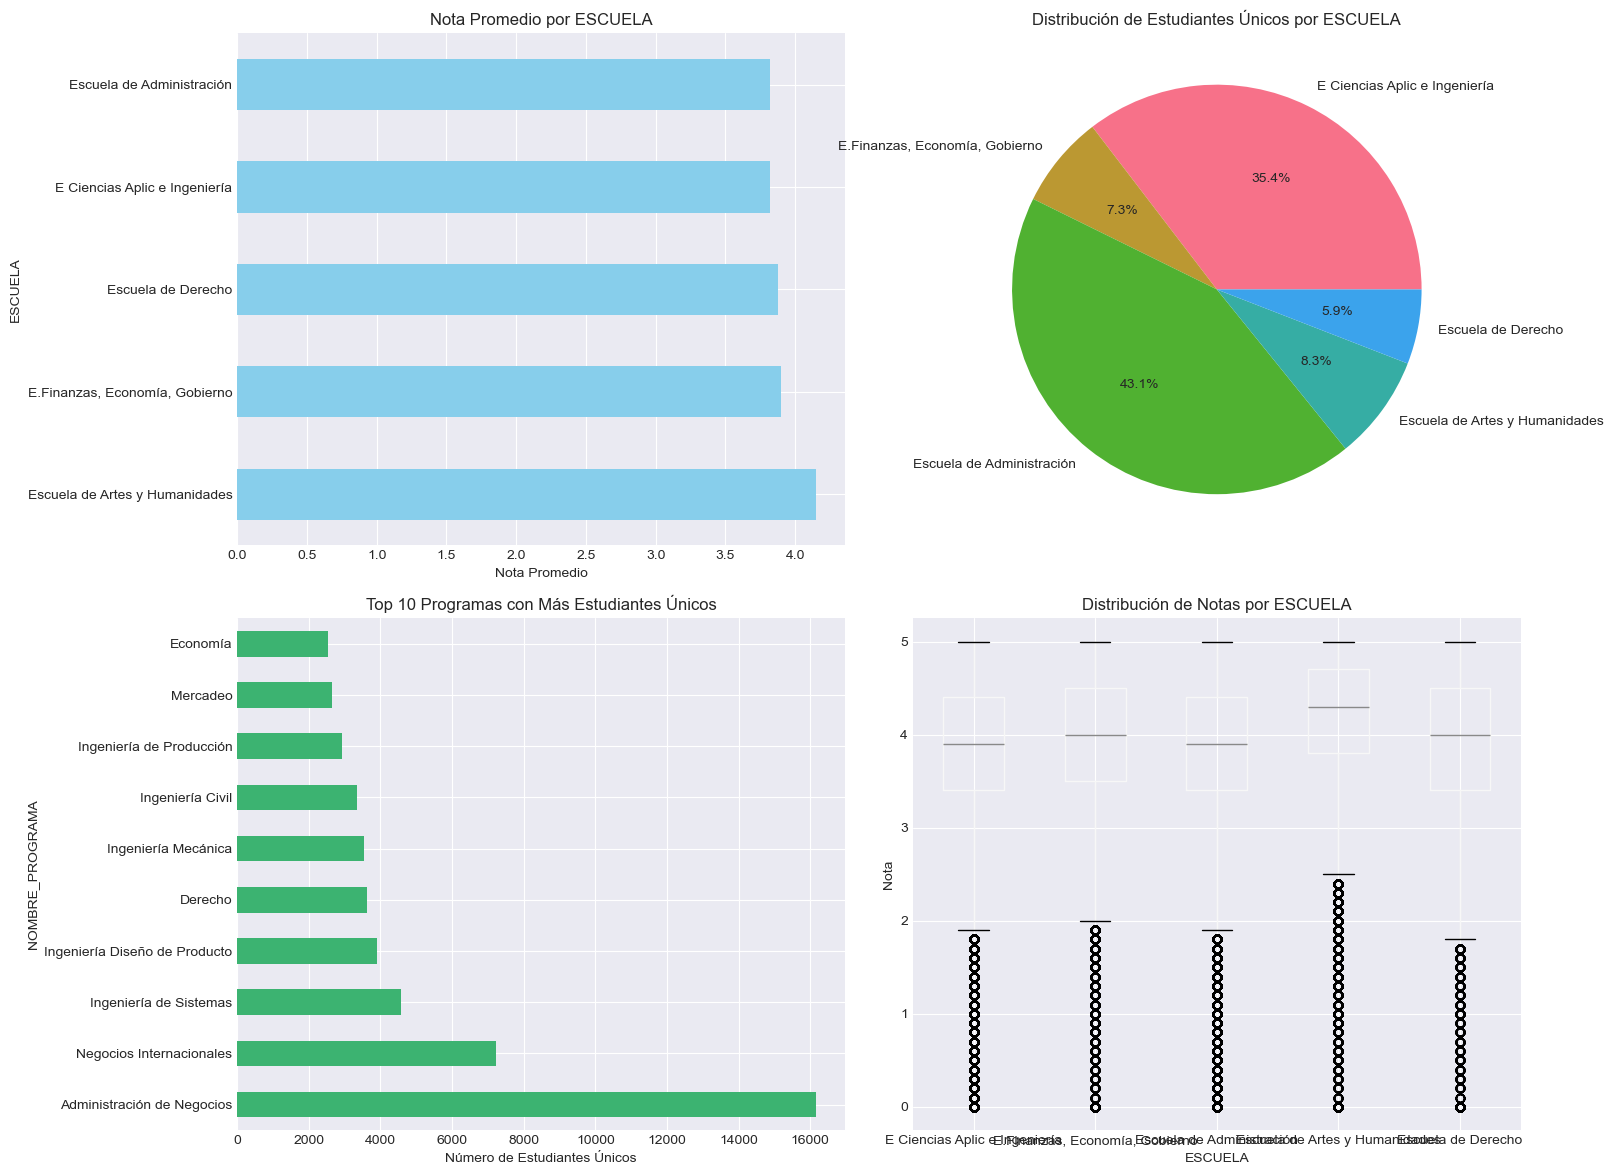


--- Top 10 Programas con Mejor Nota Promedio (mínimo 50 estudiantes) ---
                       mean  estudiantes
NOMBRE_PROGRAMA                         
Literatura             4.34          146
Música                 4.34          899
Diseño Interactivo     4.21          505
Nivelatorio de Música  4.16          491
Psicología             4.13         1050
Ingeniería Matemática  4.09          572
Comunicación Social    4.06         2462
Ingeniería Agronómica  4.04          173
Mercadeo               4.01         2643
Ciencias Políticas     3.98          904

--- Top 10 Programas con Menor Nota Promedio (mínimo 50 estudiantes) ---
                                mean  estudiantes
NOMBRE_PROGRAMA                                  
Geología                        3.73          925
Administración de Negocios      3.73        16163
Ingeniería Civil                3.74         3352
Ingeniería Civil - Llanogrande  3.74           52
Administración de Negocios Llg  3.75          195
Ingeniería

In [23]:
analizar_escuelas_programas(notas)

# 7. ANÁLISIS DE CARACTERÍSTICAS DEMOGRÁFICAS

In [26]:
def analizar_demografico(df):
    """
    Análisis de características demográficas y socioeconómicas
    """
    print("\n" + "="*80)
    print("ANÁLISIS DEMOGRÁFICO Y SOCIOECONÓMICO")
    print("="*80)
    
    total_registros = len(df)
    
    # Análisis por estrato
    if 'ESTRATO' in df.columns:
        print("\n--- Distribución por ESTRATO ---")
        dist_estrato = df['ESTRATO'].value_counts().sort_index()
        pct_estrato = (dist_estrato / total_registros * 100).round(2)
        tabla_estrato = pd.DataFrame({
            'Count': dist_estrato,
            'Porcentaje (%)': pct_estrato
        })
        print(tabla_estrato)
        
        notas_por_estrato = df.groupby('ESTRATO')['NOTA'].agg(['mean', 'median', 'count']).round(2)
        notas_por_estrato['porcentaje'] = (notas_por_estrato['count'] / total_registros * 100).round(2)
        print("\n--- Notas por ESTRATO ---")
        print(notas_por_estrato)
    
    # Análisis First Generation
    if 'FIRST_GENERATION' in df.columns:
        print("\n--- First Generation ---")
        dist_first_gen = df['FIRST_GENERATION'].value_counts()
        pct_first_gen = (dist_first_gen / total_registros * 100).round(2)
        tabla_first_gen = pd.DataFrame({
            'Count': dist_first_gen,
            'Porcentaje (%)': pct_first_gen
        })
        print(tabla_first_gen)
        
        notas_first_gen = df.groupby('FIRST_GENERATION')['NOTA'].agg(['mean', 'count']).round(2)
        notas_first_gen['porcentaje'] = (notas_first_gen['count'] / total_registros * 100).round(2)
        print("\n--- Notas por First Generation ---")
        print(notas_first_gen)
    
    # Análisis Discapacidad
    if 'DISCAPACIDAD' in df.columns:
        print("\n--- Discapacidad ---")
        dist_discapacidad = df['DISCAPACIDAD'].value_counts()
        pct_discapacidad = (dist_discapacidad / total_registros * 100).round(2)
        tabla_discapacidad = pd.DataFrame({
            'Count': dist_discapacidad,
            'Porcentaje (%)': pct_discapacidad
        })
        print(tabla_discapacidad)
        
        if df['DISCAPACIDAD'].notna().sum() > 0:
            notas_discapacidad = df.groupby('DISCAPACIDAD')['NOTA'].agg(['mean', 'count']).round(2)
            notas_discapacidad['porcentaje'] = (notas_discapacidad['count'] / total_registros * 100).round(2)
            print("\n--- Notas por Tipo de Discapacidad ---")
            print(notas_discapacidad)
    
    # Análisis Desplazados
    if 'DESPLAZADO_VICTIMA_CONFLICTO' in df.columns:
        print("\n--- Desplazados Víctimas del Conflicto ---")
        dist_desplazados = df['DESPLAZADO_VICTIMA_CONFLICTO'].value_counts()
        pct_desplazados = (dist_desplazados / total_registros * 100).round(2)
        tabla_desplazados = pd.DataFrame({
            'Count': dist_desplazados,
            'Porcentaje (%)': pct_desplazados
        })
        print(tabla_desplazados)
        
        notas_desplazados = df.groupby('DESPLAZADO_VICTIMA_CONFLICTO')['NOTA'].agg(['mean', 'count']).round(2)
        notas_desplazados['porcentaje'] = (notas_desplazados['count'] / total_registros * 100).round(2)
        print("\n--- Notas por Condición de Desplazamiento ---")
        print(notas_desplazados)
    
    # Visualizaciones
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Notas por estrato
    if 'ESTRATO' in df.columns:
        df.groupby('ESTRATO')['NOTA'].mean().plot(kind='bar', ax=axes[0, 0], color='coral')
        axes[0, 0].set_xlabel('ESTRATO')
        axes[0, 0].set_ylabel('Nota Promedio')
        axes[0, 0].set_title('Nota Promedio por ESTRATO')
        axes[0, 0].tick_params(axis='x', rotation=0)
    
    # Notas por First Generation
    if 'FIRST_GENERATION' in df.columns:
        df.groupby('FIRST_GENERATION')['NOTA'].mean().plot(kind='bar', ax=axes[0, 1], color='lightgreen')
        axes[0, 1].set_xlabel('First Generation')
        axes[0, 1].set_ylabel('Nota Promedio')
        axes[0, 1].set_title('Nota Promedio por First Generation')
        axes[0, 1].tick_params(axis='x', rotation=0)
    
    # Distribución por estrato
    if 'ESTRATO' in df.columns:
        df['ESTRATO'].value_counts().sort_index().plot(kind='bar', ax=axes[1, 0], color='skyblue')
        axes[1, 0].set_xlabel('ESTRATO')
        axes[1, 0].set_ylabel('Cantidad de Registros')
        axes[1, 0].set_title('Distribución de Registros por ESTRATO')
        axes[1, 0].tick_params(axis='x', rotation=0)
    
    # Boxplot estrato vs nota
    if 'ESTRATO' in df.columns:
        df.boxplot(column='NOTA', by='ESTRATO', ax=axes[1, 1])
        axes[1, 1].set_xlabel('ESTRATO')
        axes[1, 1].set_ylabel('Nota')
        axes[1, 1].set_title('Distribución de Notas por ESTRATO')
        plt.suptitle('')
    
    plt.tight_layout()
    plt.show()


ANÁLISIS DEMOGRÁFICO Y SOCIOECONÓMICO

--- Distribución por ESTRATO ---
          Count  Porcentaje (%)
ESTRATO                        
1         33205            1.51
2        123685            5.64
3        287327           13.09
4        289249           13.18
5        419573           19.12
6        411387           18.75

--- Notas por ESTRATO ---
         mean  median   count  porcentaje
ESTRATO                                  
1        3.81     4.0   33205        1.51
2        3.93     4.1  123685        5.64
3        3.92     4.0  287327       13.09
4        3.86     4.0  289249       13.18
5        3.88     4.0  419573       19.12
6        3.90     4.0  411387       18.75

--- First Generation ---
                    Count  Porcentaje (%)
FIRST_GENERATION                         
True              1325941           60.42
False              868671           39.58

--- Notas por First Generation ---
                  mean    count  porcentaje
FIRST_GENERATION                  

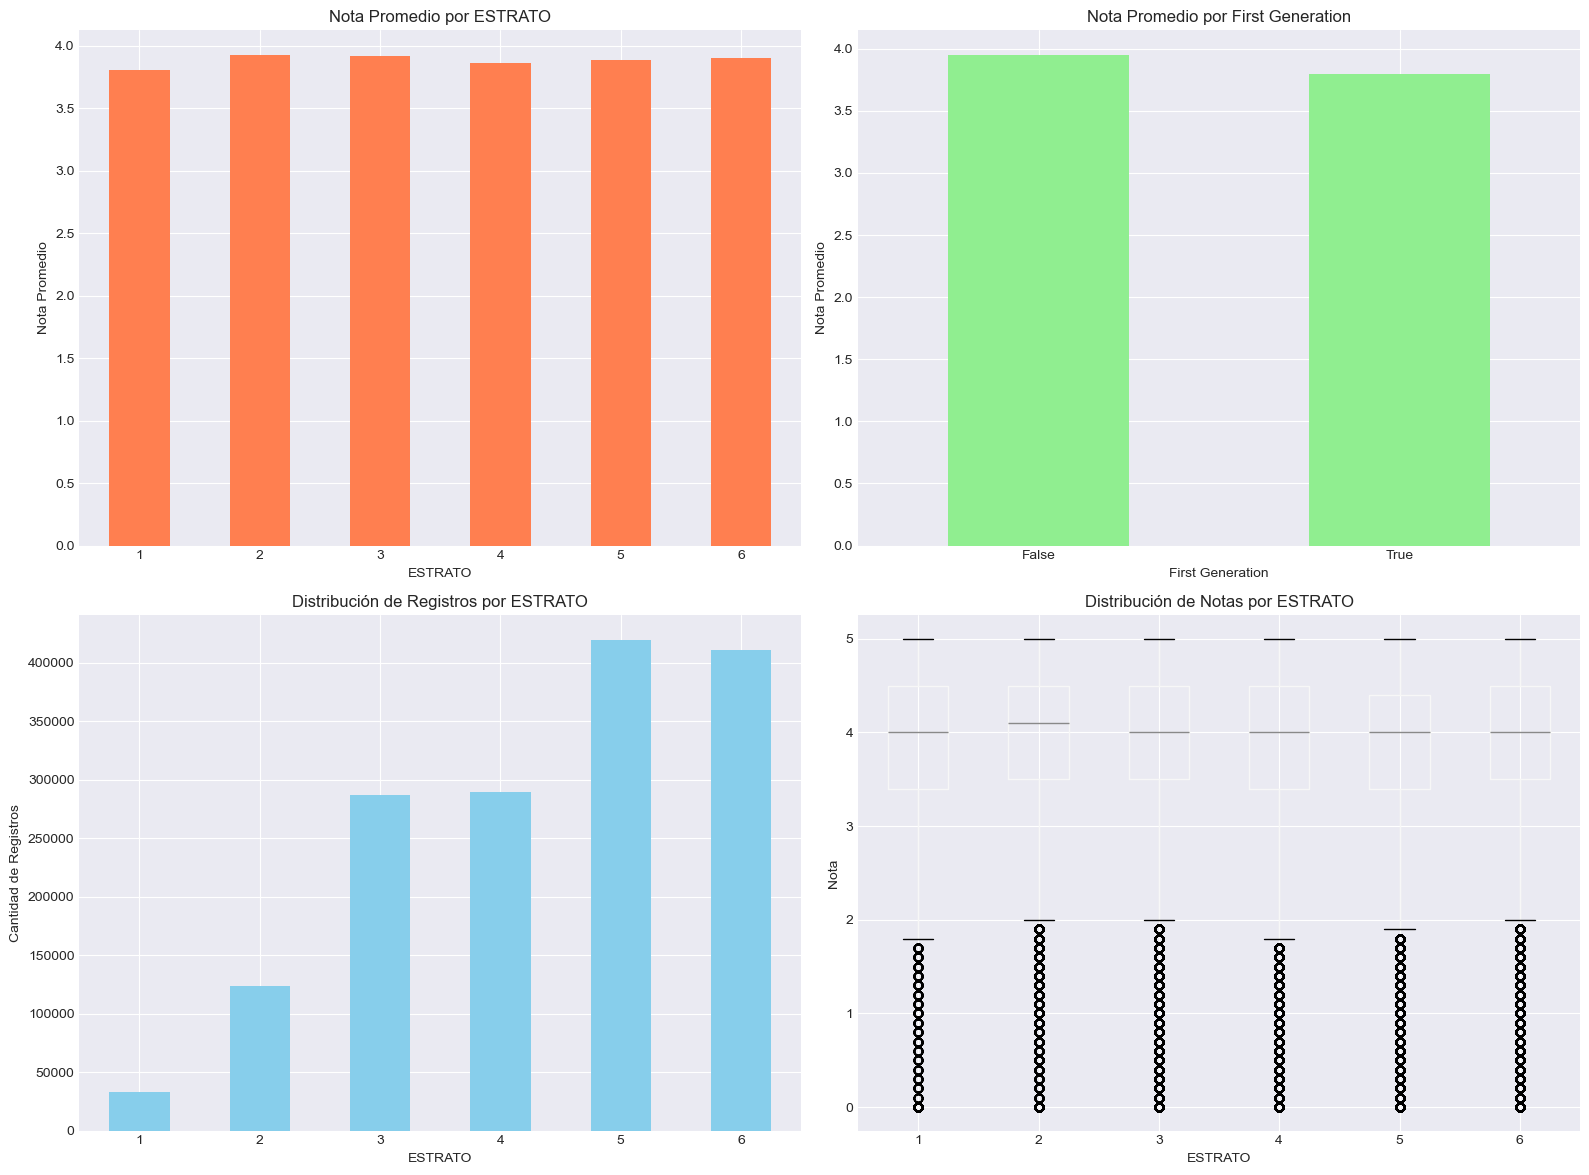

In [27]:
analizar_demografico(notas)

# 8. ANÁLISIS DE DESERCIÓN Y GRADUACIÓN

In [43]:
def analizar_desercion_graduacion(df):
    """
    Análisis de deserción, graduación y estado activo
    """
    print("\n" + "="*80)
    print("ANÁLISIS DE DESERCIÓN Y GRADUACIÓN")
    print("="*80)
    
    # Análisis por estudiante único
    estudiantes = df.groupby('EMPLID_ANÓNIMO').agg({
        'DESERTOR': 'first',
        'GRADUADO': 'first',
        'ACTIVO': 'first',
        'NOTA': 'mean',
        'SEMESTRE': 'count',
        'COHORTE': 'first'
    }).reset_index()
    estudiantes.columns = ['EMPLID_ANÓNIMO', 'DESERTOR', 'GRADUADO', 'ACTIVO', 'NOTA_PROMEDIO', 'NUM_MATERIAS', 'COHORTE']
    
    print(f"\nNúmero total de estudiantes únicos: {len(estudiantes):,}")
    
    # Distribución de estados
    print("\n--- Distribución de Estados ---")
    print(f"Desertores: {estudiantes['DESERTOR'].sum():,} ({estudiantes['DESERTOR'].sum()/len(estudiantes)*100:.2f}%)")
    print(f"Graduados: {estudiantes['GRADUADO'].sum():,} ({estudiantes['GRADUADO'].sum()/len(estudiantes)*100:.2f}%)")
    print(f"Activos: {estudiantes['ACTIVO'].sum():,} ({estudiantes['ACTIVO'].sum()/len(estudiantes)*100:.2f}%)")
    
    # Comparación de notas
    print("\n--- Nota Promedio por Estado ---")
    print(f"Desertores: {estudiantes[estudiantes['DESERTOR']==1]['NOTA_PROMEDIO'].mean():.2f}")
    print(f"Graduados: {estudiantes[estudiantes['GRADUADO']==1]['NOTA_PROMEDIO'].mean():.2f}")
    print(f"Activos: {estudiantes[estudiantes['ACTIVO']==1]['NOTA_PROMEDIO'].mean():.2f}")
    
    # Visualizaciones - Primera figura
    fig1, axes1 = plt.subplots(2, 2, figsize=(15, 10))
    
    # Distribución de estados
    estados = pd.Series({
        'Desertores': estudiantes['DESERTOR'].sum(),
        'Graduados': estudiantes['GRADUADO'].sum(),
        'Activos': estudiantes['ACTIVO'].sum()
    })
    estados.plot(kind='pie', ax=axes1[0, 0], autopct='%1.1f%%', startangle=90)
    axes1[0, 0].set_title('Distribución de Estudiantes por Estado')
    axes1[0, 0].set_ylabel('')
    
    # Notas promedio por estado CON ETIQUETAS
    notas_estado = pd.Series({
        'Desertores': estudiantes[estudiantes['DESERTOR']==1]['NOTA_PROMEDIO'].mean(),
        'Graduados': estudiantes[estudiantes['GRADUADO']==1]['NOTA_PROMEDIO'].mean(),
        'Activos': estudiantes[estudiantes['ACTIVO']==1]['NOTA_PROMEDIO'].mean()
    })
    bars = notas_estado.plot(kind='bar', ax=axes1[0, 1], color=['red', 'green', 'blue'])
    axes1[0, 1].set_xlabel('Estado')
    axes1[0, 1].set_ylabel('Nota Promedio')
    axes1[0, 1].set_title('Nota Promedio por Estado del Estudiante')
    axes1[0, 1].tick_params(axis='x', rotation=0)
    
    # Agregar etiquetas de datos
    for i, (idx, val) in enumerate(notas_estado.items()):
        axes1[0, 1].text(i, val, f'{val:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    # Distribución de notas por estado
    for estado in ['DESERTOR', 'GRADUADO', 'ACTIVO']:
        data = estudiantes[estudiantes[estado]==1]['NOTA_PROMEDIO'].dropna()
        axes1[1, 0].hist(data, alpha=0.5, label=estado, bins=30)
    axes1[1, 0].set_xlabel('Nota Promedio')
    axes1[1, 0].set_ylabel('Frecuencia')
    axes1[1, 0].set_title('Distribución de Notas Promedio por Estado')
    axes1[1, 0].legend()
    
    # Tasa de deserción por escuela CON ETIQUETAS
    desercion_escuela = df.groupby('ESCUELA')['DESERTOR'].mean() * 100
    desercion_escuela_sorted = desercion_escuela.sort_values(ascending=True)
    bars2 = desercion_escuela_sorted.plot(kind='barh', ax=axes1[1, 1], color='salmon')
    axes1[1, 1].set_xlabel('Tasa de Deserción (%)')
    axes1[1, 1].set_title('Tasa de Deserción por ESCUELA')
    
    # Agregar etiquetas de datos
    for i, (idx, val) in enumerate(desercion_escuela_sorted.items()):
        axes1[1, 1].text(val, i, f'{val:.1f}%', ha='left', va='center', fontweight='bold', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # NUEVA GRÁFICA: Estudiantes por COHORTE y Estado
    print("\n--- Análisis por COHORTE ---")
    
    # Preparar datos por cohorte
    cohorte_desertor = estudiantes[estudiantes['DESERTOR']==1].groupby('COHORTE').size()
    cohorte_graduado = estudiantes[estudiantes['GRADUADO']==1].groupby('COHORTE').size()
    cohorte_activo = estudiantes[estudiantes['ACTIVO']==1].groupby('COHORTE').size()
    
    # Crear dataframe consolidado
    cohortes_todas = sorted(estudiantes['COHORTE'].unique())
    df_cohorte = pd.DataFrame({
        'COHORTE': cohortes_todas,
        'Desertores': [cohorte_desertor.get(c, 0) for c in cohortes_todas],
        'Graduados': [cohorte_graduado.get(c, 0) for c in cohortes_todas],
        'Activos': [cohorte_activo.get(c, 0) for c in cohortes_todas]
    })
    
    # Gráfica apilada por cohorte
    fig2, ax2 = plt.subplots(figsize=(16, 6))
    
    x = np.arange(len(df_cohorte))
    width = 0.8
    
    p1 = ax2.bar(x, df_cohorte['Desertores'], width, label='Desertores', color='#FF6B6B')
    p2 = ax2.bar(x, df_cohorte['Graduados'], width, bottom=df_cohorte['Desertores'], 
                 label='Graduados', color='#9b8cf5')
    p3 = ax2.bar(x, df_cohorte['Activos'], width, 
                 bottom=df_cohorte['Desertores'] + df_cohorte['Graduados'],
                 label='Activos', color='#95E1D3')
    
    ax2.set_xlabel('COHORTE', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Número de Estudiantes', fontsize=12, fontweight='bold')
    ax2.set_title('Distribución de Estudiantes por COHORTE y Estado', fontsize=14, fontweight='bold', pad=15)
    ax2.set_xticks(x)
    ax2.set_xticklabels(df_cohorte['COHORTE'], rotation=45, ha='right')
    ax2.legend(loc='upper left')
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Tabla resumen por cohorte
    print("\n--- Tabla: Estudiantes por COHORTE y Estado ---")
    df_cohorte['Total'] = df_cohorte['Desertores'] + df_cohorte['Graduados'] + df_cohorte['Activos']
    df_cohorte['% Deserción'] = (df_cohorte['Desertores'] / df_cohorte['Total'] * 100).round(2)
    df_cohorte['% Graduación'] = (df_cohorte['Graduados'] / df_cohorte['Total'] * 100).round(2)
    print(df_cohorte.to_string(index=False))
       
    plt.tight_layout()
    plt.show()


ANÁLISIS DE DESERCIÓN Y GRADUACIÓN

Número total de estudiantes únicos: 58,406

--- Distribución de Estados ---
Desertores: 19,544 (33.46%)
Graduados: 30,406 (52.06%)
Activos: 9,034 (15.47%)

--- Nota Promedio por Estado ---
Desertores: 3.14
Graduados: 3.96
Activos: 3.99


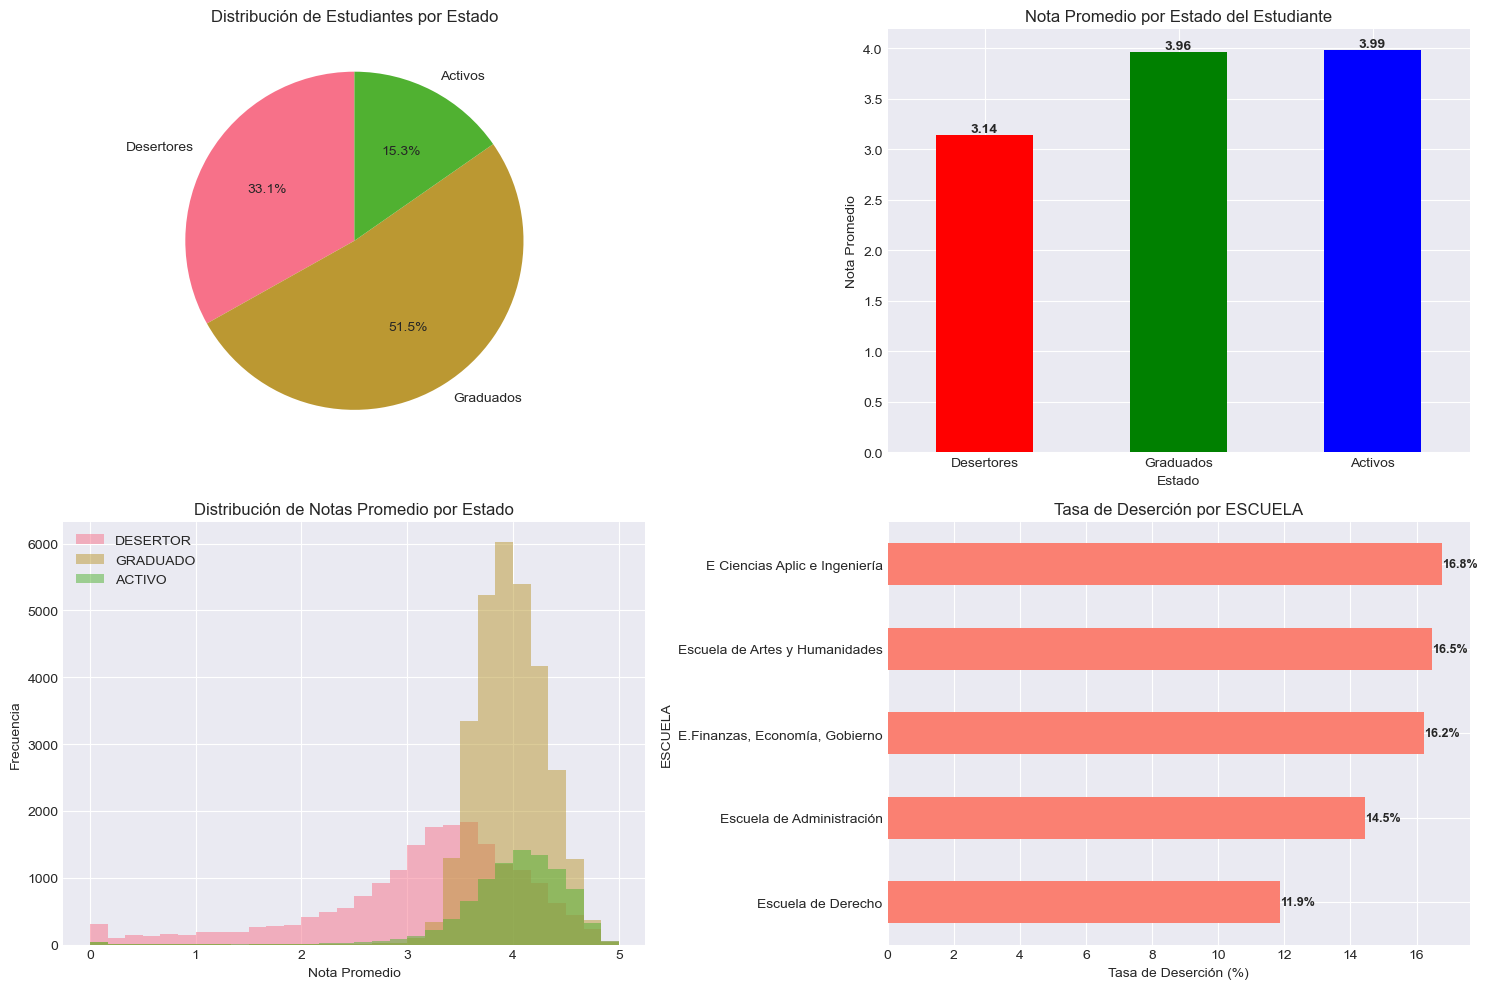


--- Análisis por COHORTE ---


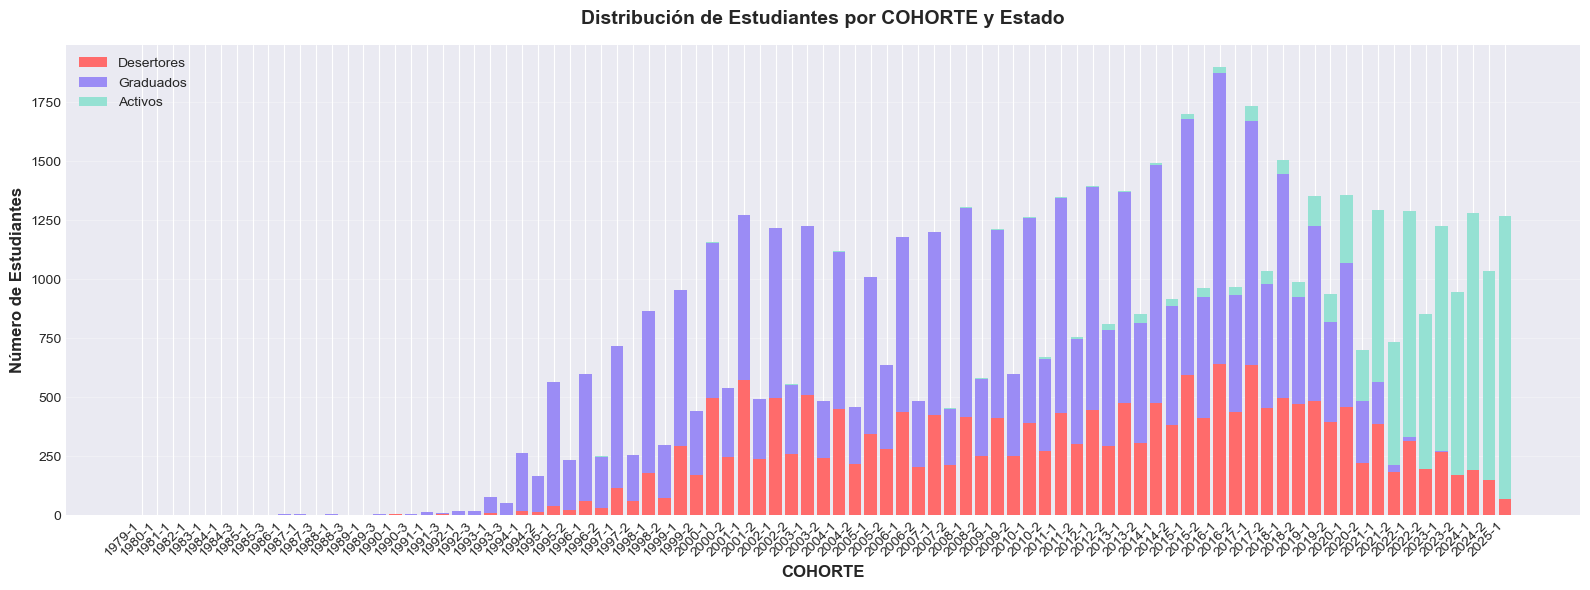


--- Tabla: Estudiantes por COHORTE y Estado ---
COHORTE  Desertores  Graduados  Activos  Total  % Deserción  % Graduación
 1979-1           0          2        0      2         0.00        100.00
 1980-1           1          0        0      1       100.00          0.00
 1981-1           0          1        0      1         0.00        100.00
 1982-1           0          1        0      1         0.00        100.00
 1983-1           0          2        0      2         0.00        100.00
 1984-1           1          0        0      1       100.00          0.00
 1984-3           1          0        0      1       100.00          0.00
 1985-1           0          1        0      1         0.00        100.00
 1985-3           0          1        0      1         0.00        100.00
 1986-1           0          4        0      4         0.00        100.00
 1987-1           2          3        0      5        40.00         60.00
 1987-3           0          1        0      1         0.00    

<Figure size 1200x600 with 0 Axes>

In [44]:
analizar_desercion_graduacion(notas)

# 9. ANÁLISIS DE CRÉDITOS

In [45]:
def analizar_creditos(df):
    """
    Análisis de créditos académicos
    """
    print("\n" + "="*80)
    print("ANÁLISIS DE CRÉDITOS")
    print("="*80)
    
    print("\n--- Estadísticas de Créditos ---")
    print(df['CRÉDITOS'].describe())
    
    print(f"\nTotal de créditos registrados: {df['CRÉDITOS'].sum():,.0f}")
    print(f"Promedio de créditos por materia: {df['CRÉDITOS'].mean():.2f}")
    
    # Distribución de créditos
    print("\n--- Distribución de Créditos por Materia ---")
    print(df['CRÉDITOS'].value_counts().sort_index())
    
    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    df['CRÉDITOS'].value_counts().sort_index().plot(kind='bar', ax=axes[0])
    axes[0].set_xlabel('Número de Créditos')
    axes[0].set_ylabel('Frecuencia')
    axes[0].set_title('Distribución de Créditos por Materia')
    
    # Relación créditos vs nota
    creditos_nota = df.groupby('CRÉDITOS')['NOTA'].mean()
    creditos_nota.plot(kind='line', marker='o', ax=axes[1])
    axes[1].set_xlabel('Número de Créditos')
    axes[1].set_ylabel('Nota Promedio')
    axes[1].set_title('Nota Promedio según Número de Créditos')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


ANÁLISIS DE CRÉDITOS

--- Estadísticas de Créditos ---
count    2.194612e+06
mean     3.326536e+00
std      2.139776e+00
min      1.000000e+00
25%      3.000000e+00
50%      3.000000e+00
75%      3.000000e+00
max      2.400000e+01
Name: CRÉDITOS, dtype: float64

Total de créditos registrados: 7,300,455
Promedio de créditos por materia: 3.33

--- Distribución de Créditos por Materia ---
CRÉDITOS
1      113345
2      188247
3     1389476
4      415512
5        4715
6       42459
7          22
8        4815
9         104
10       1408
11          1
12         71
16          5
18      20733
20      13698
24          1
Name: count, dtype: int64


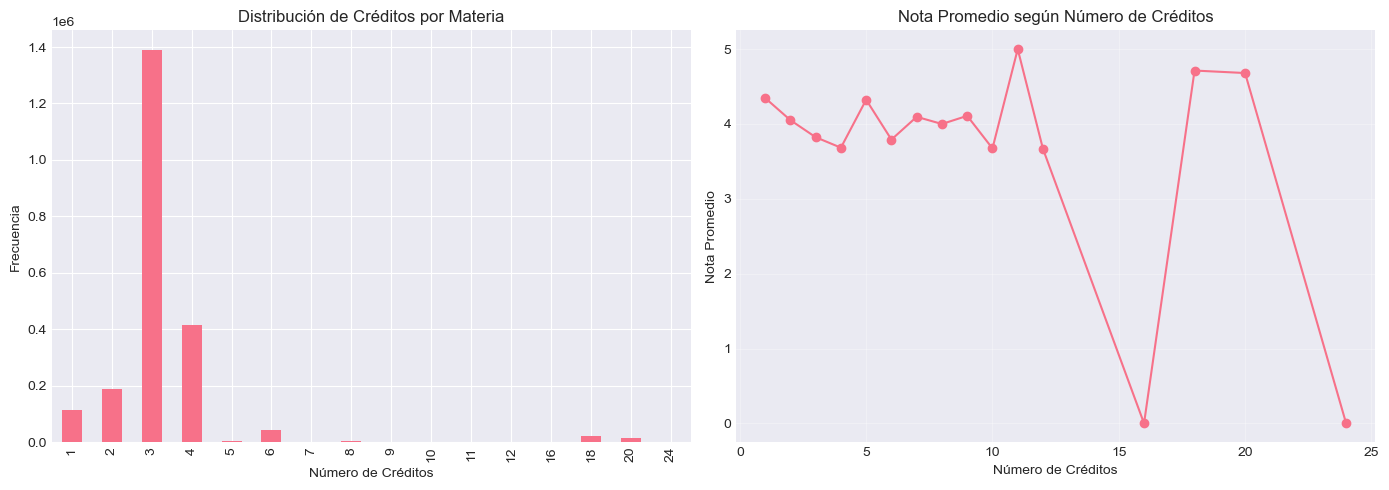

In [46]:
analizar_creditos(notas)

# 10. CORRELACIONES Y RELACIONES

In [55]:
def analizar_correlaciones(df):
    """
    Análisis de correlaciones entre variables numéricas y categóricas
    """
    print("\n" + "="*80)
    print("ANÁLISIS DE CORRELACIONES Y RELACIONES")
    print("="*80)
    
    # ========================================================================
    # 1. CORRELACIÓN ENTRE VARIABLES NUMÉRICAS
    # ========================================================================
    print("\n" + "-"*80)
    print("1. CORRELACIÓN ENTRE VARIABLES NUMÉRICAS")
    print("-"*80)
    
    # Seleccionar variables numéricas relevantes
    num_cols = ['NOTA', 'CRÉDITOS']
    
    # Agregar variables derivadas por estudiante
    estudiantes_metricas = df.groupby('EMPLID_ANÓNIMO').agg({
        'NOTA': 'mean',
        'CRÉDITOS': 'sum',
        'SEMESTRE': 'count',
        'DESERTOR': 'first',
        'GRADUADO': 'first',
        'ACTIVO': 'first'
    }).reset_index()
    estudiantes_metricas.columns = ['EMPLID_ANÓNIMO', 'NOTA_PROMEDIO', 'CREDITOS_TOTALES', 
                                     'NUM_MATERIAS', 'DESERTOR', 'GRADUADO', 'ACTIVO']
    
    # Matriz de correlación de variables numéricas
    corr_vars = ['NOTA_PROMEDIO', 'CREDITOS_TOTALES', 'NUM_MATERIAS', 'DESERTOR', 'GRADUADO', 'ACTIVO']
    corr_matrix = estudiantes_metricas[corr_vars].corr()
    
    print("\n--- Matriz de Correlación ---")
    print(corr_matrix.round(3))
    
    # Visualización
    fig1, ax1 = plt.subplots(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
                center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    ax1.set_title('Matriz de Correlación - Variables Numéricas', fontsize=14, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()
    
    # Identificar correlaciones más fuertes
    print("\n--- Correlaciones más fuertes (|r| > 0.3) ---")
    correlaciones_fuertes = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_val = corr_matrix.iloc[i, j]
            if abs(corr_val) > 0.3:
                correlaciones_fuertes.append({
                    'Variable 1': corr_matrix.columns[i],
                    'Variable 2': corr_matrix.columns[j],
                    'Correlación': corr_val
                })
    
    if correlaciones_fuertes:
        df_corr_fuertes = pd.DataFrame(correlaciones_fuertes).sort_values('Correlación', 
                                                                           key=abs, ascending=False)
        print(df_corr_fuertes.to_string(index=False))
    else:
        print("No se encontraron correlaciones fuertes (|r| > 0.3)")
    
    # ========================================================================
    # 2. RELACIÓN ENTRE VARIABLES CATEGÓRICAS Y NOTA
    # ========================================================================
    print("\n" + "-"*80)
    print("2. RELACIÓN ENTRE VARIABLES CATEGÓRICAS Y NOTA")
    print("-"*80)
    
    # Variables categóricas a analizar
    cat_vars = []
    if 'ESTRATO' in df.columns:
        cat_vars.append('ESTRATO')
    if 'FIRST_GENERATION' in df.columns:
        cat_vars.append('FIRST_GENERATION')
    if 'ESCUELA' in df.columns:
        cat_vars.append('ESCUELA')
    if 'DESPLAZADO_VICTIMA_CONFLICTO' in df.columns:
        cat_vars.append('DESPLAZADO_VICTIMA_CONFLICTO')
    
    # Análisis de varianza (ANOVA) - F-statistic
    print("\n--- Análisis de Varianza (ANOVA) ---")
    print("Mide si las diferencias de NOTA entre categorías son estadísticamente significativas")
    print("F-statistic alto = Mayor diferencia entre grupos\n")
    
    from scipy import stats
    
    anova_results = []
    for var in cat_vars:
        grupos = [group['NOTA'].dropna() for name, group in df.groupby(var)]
        if len(grupos) > 1:
            f_stat, p_value = stats.f_oneway(*grupos)
            anova_results.append({
                'Variable': var,
                'F-statistic': f_stat,
                'p-value': p_value,
                'Significativo': 'Sí' if p_value < 0.05 else 'No'
            })
    
    if anova_results:
        df_anova = pd.DataFrame(anova_results).sort_values('F-statistic', ascending=False)
        print(df_anova.to_string(index=False))
    
    # ========================================================================
    # 3. BOXPLOTS COMPARATIVOS
    # ========================================================================
    print("\n" + "-"*80)
    print("3. VISUALIZACIÓN DE RELACIONES CATEGÓRICAS")
    print("-"*80)
    
    # Crear subplots para las variables más relevantes
    n_plots = min(4, len(cat_vars))
    if n_plots > 0:
        fig2, axes2 = plt.subplots(2, 2, figsize=(16, 12))
        axes2 = axes2.flatten()
        
        for idx, var in enumerate(cat_vars[:4]):
            df.boxplot(column='NOTA', by=var, ax=axes2[idx])
            axes2[idx].set_xlabel(var, fontsize=11, fontweight='bold')
            axes2[idx].set_ylabel('NOTA', fontsize=11, fontweight='bold')
            axes2[idx].set_title(f'Distribución de NOTA por {var}', fontsize=12, fontweight='bold')
            axes2[idx].tick_params(axis='x', rotation=45)
        
        # Ocultar subplots vacíos
        for idx in range(n_plots, 4):
            axes2[idx].set_visible(False)
        
        plt.suptitle('')
        plt.tight_layout()
        plt.show()
    
    # ========================================================================
    # 4. ANÁLISIS DE CONTINGENCIA - VARIABLES CATEGÓRICAS vs ESTADO
    # ========================================================================
    print("\n" + "-"*80)
    print("4. RELACIÓN ENTRE VARIABLES DEMOGRÁFICAS Y ESTADO DEL ESTUDIANTE")
    print("-"*80)
    
    # Unir métricas de estudiantes con variables categóricas
    estudiantes_full = df.groupby('EMPLID_ANÓNIMO').agg({
        'DESERTOR': 'first',
        'GRADUADO': 'first',
        'ACTIVO': 'first',
        'ESTRATO': 'first' if 'ESTRATO' in df.columns else 'count',
        'FIRST_GENERATION': 'first' if 'FIRST_GENERATION' in df.columns else 'count',
        'DISCAPACIDAD': 'first' if 'DISCAPACIDAD' in df.columns else 'count',
        'DESPLAZADO_VICTIMA_CONFLICTO': 'first' if 'DESPLAZADO_VICTIMA_CONFLICTO' in df.columns else 'count'
    }).reset_index()
    
    # Crear variable de estado
    estudiantes_full['ESTADO'] = estudiantes_full.apply(
        lambda x: 'Desertor' if x['DESERTOR'] == 1 else ('Graduado' if x['GRADUADO'] == 1 else 'Activo'), 
        axis=1
    )
    
    # Análisis por ESTRATO
    if 'ESTRATO' in df.columns:
        print("\n--- Tasa de Deserción por ESTRATO ---")
        desercion_estrato = estudiantes_full.groupby('ESTRATO')['DESERTOR'].agg(['sum', 'count'])
        desercion_estrato['Tasa_Desercion_%'] = (desercion_estrato['sum'] / desercion_estrato['count'] * 100).round(2)
        desercion_estrato.columns = ['Desertores', 'Total_Estudiantes', 'Tasa_Desercion_%']
        print(desercion_estrato.sort_values('Tasa_Desercion_%', ascending=False))
    
    # Análisis por FIRST_GENERATION
    if 'FIRST_GENERATION' in df.columns:
        print("\n--- Tasa de Deserción por FIRST_GENERATION ---")
        desercion_fg = estudiantes_full.groupby('FIRST_GENERATION')['DESERTOR'].agg(['sum', 'count'])
        desercion_fg['Tasa_Desercion_%'] = (desercion_fg['sum'] / desercion_fg['count'] * 100).round(2)
        desercion_fg.columns = ['Desertores', 'Total_Estudiantes', 'Tasa_Desercion_%']
        print(desercion_fg)
    
    # Análisis por DISCAPACIDAD
    if 'DISCAPACIDAD' in df.columns and estudiantes_full['DISCAPACIDAD'].notna().sum() > 0:
        print("\n--- Tasa de Deserción por DISCAPACIDAD ---")
        desercion_disc = estudiantes_full[estudiantes_full['DISCAPACIDAD'].notna()].groupby('DISCAPACIDAD')['DESERTOR'].agg(['sum', 'count'])
        desercion_disc['Tasa_Desercion_%'] = (desercion_disc['sum'] / desercion_disc['count'] * 100).round(2)
        desercion_disc.columns = ['Desertores', 'Total_Estudiantes', 'Tasa_Desercion_%']
        print(desercion_disc.sort_values('Tasa_Desercion_%', ascending=False))
    
    # ========================================================================
    # 5. VISUALIZACIÓN DE TASAS DE DESERCIÓN POR CATEGORÍAS
    # ========================================================================
    print("\n" + "-"*80)
    print("5. VISUALIZACIÓN DE TASAS DE DESERCIÓN")
    print("-"*80)
    
    # Determinar número de gráficas a mostrar
    n_graficas = 2  # ESTRATO y FIRST_GENERATION siempre
    if 'DISCAPACIDAD' in df.columns and estudiantes_full['DISCAPACIDAD'].notna().sum() > 0:
        n_graficas += 1
    if 'DESPLAZADO_VICTIMA_CONFLICTO' in df.columns:
        n_graficas += 1
    
    # Crear figura con el número apropiado de subplots
    if n_graficas == 2:
        fig3, axes3 = plt.subplots(1, 2, figsize=(16, 6))
        axes3 = [axes3[0], axes3[1]]
    elif n_graficas == 3:
        fig3, axes3 = plt.subplots(1, 3, figsize=(18, 6))
        axes3 = [axes3[0], axes3[1], axes3[2]]
    else:  # 4 gráficas
        fig3, axes3 = plt.subplots(2, 2, figsize=(16, 12))
        axes3 = [axes3[0, 0], axes3[0, 1], axes3[1, 0], axes3[1, 1]]
    
    idx_grafica = 0
    
    # Tasa de deserción por ESTRATO
    if 'ESTRATO' in df.columns:
        desercion_estrato['Tasa_Desercion_%'].plot(kind='bar', ax=axes3[idx_grafica], color='coral')
        axes3[idx_grafica].set_xlabel('ESTRATO', fontsize=12, fontweight='bold')
        axes3[idx_grafica].set_ylabel('Tasa de Deserción (%)', fontsize=12, fontweight='bold')
        axes3[idx_grafica].set_title('Tasa de Deserción por ESTRATO', fontsize=13, fontweight='bold')
        axes3[idx_grafica].tick_params(axis='x', rotation=0)
        axes3[idx_grafica].grid(True, alpha=0.3, axis='y')
        
        # Agregar etiquetas
        for i, val in enumerate(desercion_estrato['Tasa_Desercion_%']):
            axes3[idx_grafica].text(i, val, f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')
        idx_grafica += 1
    
    # Tasa de deserción por FIRST_GENERATION
    if 'FIRST_GENERATION' in df.columns:
        desercion_fg['Tasa_Desercion_%'].plot(kind='bar', ax=axes3[idx_grafica], color='steelblue')
        axes3[idx_grafica].set_xlabel('FIRST_GENERATION', fontsize=12, fontweight='bold')
        axes3[idx_grafica].set_ylabel('Tasa de Deserción (%)', fontsize=12, fontweight='bold')
        axes3[idx_grafica].set_title('Tasa de Deserción por First Generation', fontsize=13, fontweight='bold')
        axes3[idx_grafica].tick_params(axis='x', rotation=0)
        axes3[idx_grafica].grid(True, alpha=0.3, axis='y')
        
        # Agregar etiquetas
        for i, val in enumerate(desercion_fg['Tasa_Desercion_%']):
            axes3[idx_grafica].text(i, val, f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')
        idx_grafica += 1
    
    # Tasa de deserción por DISCAPACIDAD
    if 'DISCAPACIDAD' in df.columns and estudiantes_full['DISCAPACIDAD'].notna().sum() > 0:
        desercion_disc_sorted = desercion_disc.sort_values('Tasa_Desercion_%', ascending=False)
        desercion_disc_sorted['Tasa_Desercion_%'].plot(kind='barh', ax=axes3[idx_grafica], color='mediumpurple')
        axes3[idx_grafica].set_xlabel('Tasa de Deserción (%)', fontsize=12, fontweight='bold')
        axes3[idx_grafica].set_ylabel('DISCAPACIDAD', fontsize=12, fontweight='bold')
        axes3[idx_grafica].set_title('Tasa de Deserción por DISCAPACIDAD', fontsize=13, fontweight='bold')
        axes3[idx_grafica].grid(True, alpha=0.3, axis='x')
        
        # Agregar etiquetas
        for i, val in enumerate(desercion_disc_sorted['Tasa_Desercion_%']):
            axes3[idx_grafica].text(val, i, f'{val:.1f}%', ha='left', va='center', fontweight='bold')
        idx_grafica += 1
    
    # Tasa de deserción por DESPLAZADO_VICTIMA_CONFLICTO
    if 'DESPLAZADO_VICTIMA_CONFLICTO' in df.columns:
        desercion_desplazados = estudiantes_full.groupby('DESPLAZADO_VICTIMA_CONFLICTO')['DESERTOR'].agg(['sum', 'count'])
        desercion_desplazados['Tasa_Desercion_%'] = (desercion_desplazados['sum'] / desercion_desplazados['count'] * 100).round(2)
        desercion_desplazados.columns = ['Desertores', 'Total_Estudiantes', 'Tasa_Desercion_%']
        
        desercion_desplazados['Tasa_Desercion_%'].plot(kind='bar', ax=axes3[idx_grafica], color='darkorange')
        axes3[idx_grafica].set_xlabel('DESPLAZADO_VICTIMA_CONFLICTO', fontsize=12, fontweight='bold')
        axes3[idx_grafica].set_ylabel('Tasa de Deserción (%)', fontsize=12, fontweight='bold')
        axes3[idx_grafica].set_title('Tasa de Deserción por Desplazamiento', fontsize=13, fontweight='bold')
        axes3[idx_grafica].tick_params(axis='x', rotation=0)
        axes3[idx_grafica].grid(True, alpha=0.3, axis='y')
        
        # Agregar etiquetas
        for i, val in enumerate(desercion_desplazados['Tasa_Desercion_%']):
            axes3[idx_grafica].text(i, val, f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')
        
        print("\n--- Tasa de Deserción por DESPLAZADO_VICTIMA_CONFLICTO ---")
        print(desercion_desplazados)
        idx_grafica += 1
    
    plt.tight_layout()
    plt.show()
    
    # ========================================================================
    # 6. RESUMEN DE HALLAZGOS
    # ========================================================================
    print("\n" + "="*80)
    print("RESUMEN DE HALLAZGOS CLAVE")
    print("="*80)
    
    print(f"""
    CORRELACIONES NUMÉRICAS:
    • Se encontraron {len(correlaciones_fuertes) if correlaciones_fuertes else 0} correlaciones fuertes (|r| > 0.3)
    
    VARIABLES CATEGÓRICAS SIGNIFICATIVAS:
    • Variables con impacto significativo en NOTA (p < 0.05): {len([r for r in anova_results if r['p-value'] < 0.05])}
    
    FACTORES DE RIESGO DE DESERCIÓN:
    • Estrato con mayor deserción: {desercion_estrato['Tasa_Desercion_%'].idxmax() if 'ESTRATO' in df.columns else 'N/A'}
    • First Generation con mayor deserción: {desercion_fg['Tasa_Desercion_%'].idxmax() if 'FIRST_GENERATION' in df.columns else 'N/A'}
    """)


ANÁLISIS DE CORRELACIONES Y RELACIONES

--------------------------------------------------------------------------------
1. CORRELACIÓN ENTRE VARIABLES NUMÉRICAS
--------------------------------------------------------------------------------

--- Matriz de Correlación ---
                  NOTA_PROMEDIO  CREDITOS_TOTALES  NUM_MATERIAS  DESERTOR  \
NOTA_PROMEDIO             1.000             0.320         0.333    -0.529   
CREDITOS_TOTALES          0.320             1.000         0.962    -0.618   
NUM_MATERIAS              0.333             0.962         1.000    -0.616   
DESERTOR                 -0.529            -0.618        -0.616     1.000   
GRADUADO                  0.356             0.713         0.665    -0.718   
ACTIVO                    0.159            -0.219        -0.159    -0.274   

                  GRADUADO  ACTIVO  
NOTA_PROMEDIO        0.356   0.159  
CREDITOS_TOTALES     0.713  -0.219  
NUM_MATERIAS         0.665  -0.159  
DESERTOR            -0.718  -0.274  


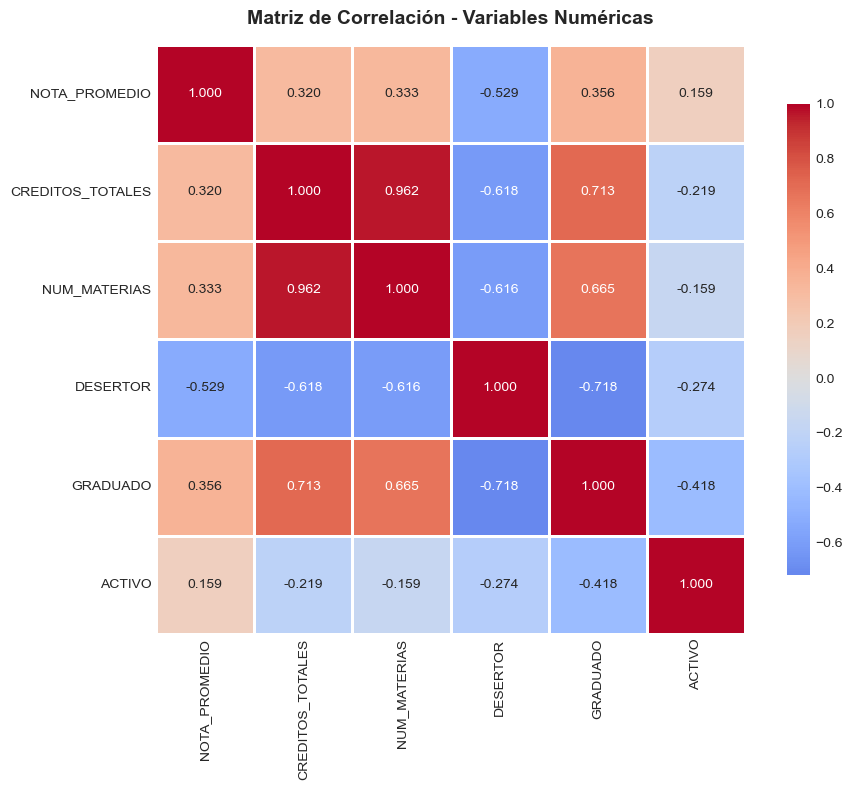


--- Correlaciones más fuertes (|r| > 0.3) ---
      Variable 1       Variable 2  Correlación
CREDITOS_TOTALES     NUM_MATERIAS     0.961941
        DESERTOR         GRADUADO    -0.718010
CREDITOS_TOTALES         GRADUADO     0.712588
    NUM_MATERIAS         GRADUADO     0.665306
CREDITOS_TOTALES         DESERTOR    -0.618155
    NUM_MATERIAS         DESERTOR    -0.616057
   NOTA_PROMEDIO         DESERTOR    -0.529210
        GRADUADO           ACTIVO    -0.418368
   NOTA_PROMEDIO         GRADUADO     0.355902
   NOTA_PROMEDIO     NUM_MATERIAS     0.332835
   NOTA_PROMEDIO CREDITOS_TOTALES     0.320098

--------------------------------------------------------------------------------
2. RELACIÓN ENTRE VARIABLES CATEGÓRICAS Y NOTA
--------------------------------------------------------------------------------

--- Análisis de Varianza (ANOVA) ---
Mide si las diferencias de NOTA entre categorías son estadísticamente significativas
F-statistic alto = Mayor diferencia entre grupos

      

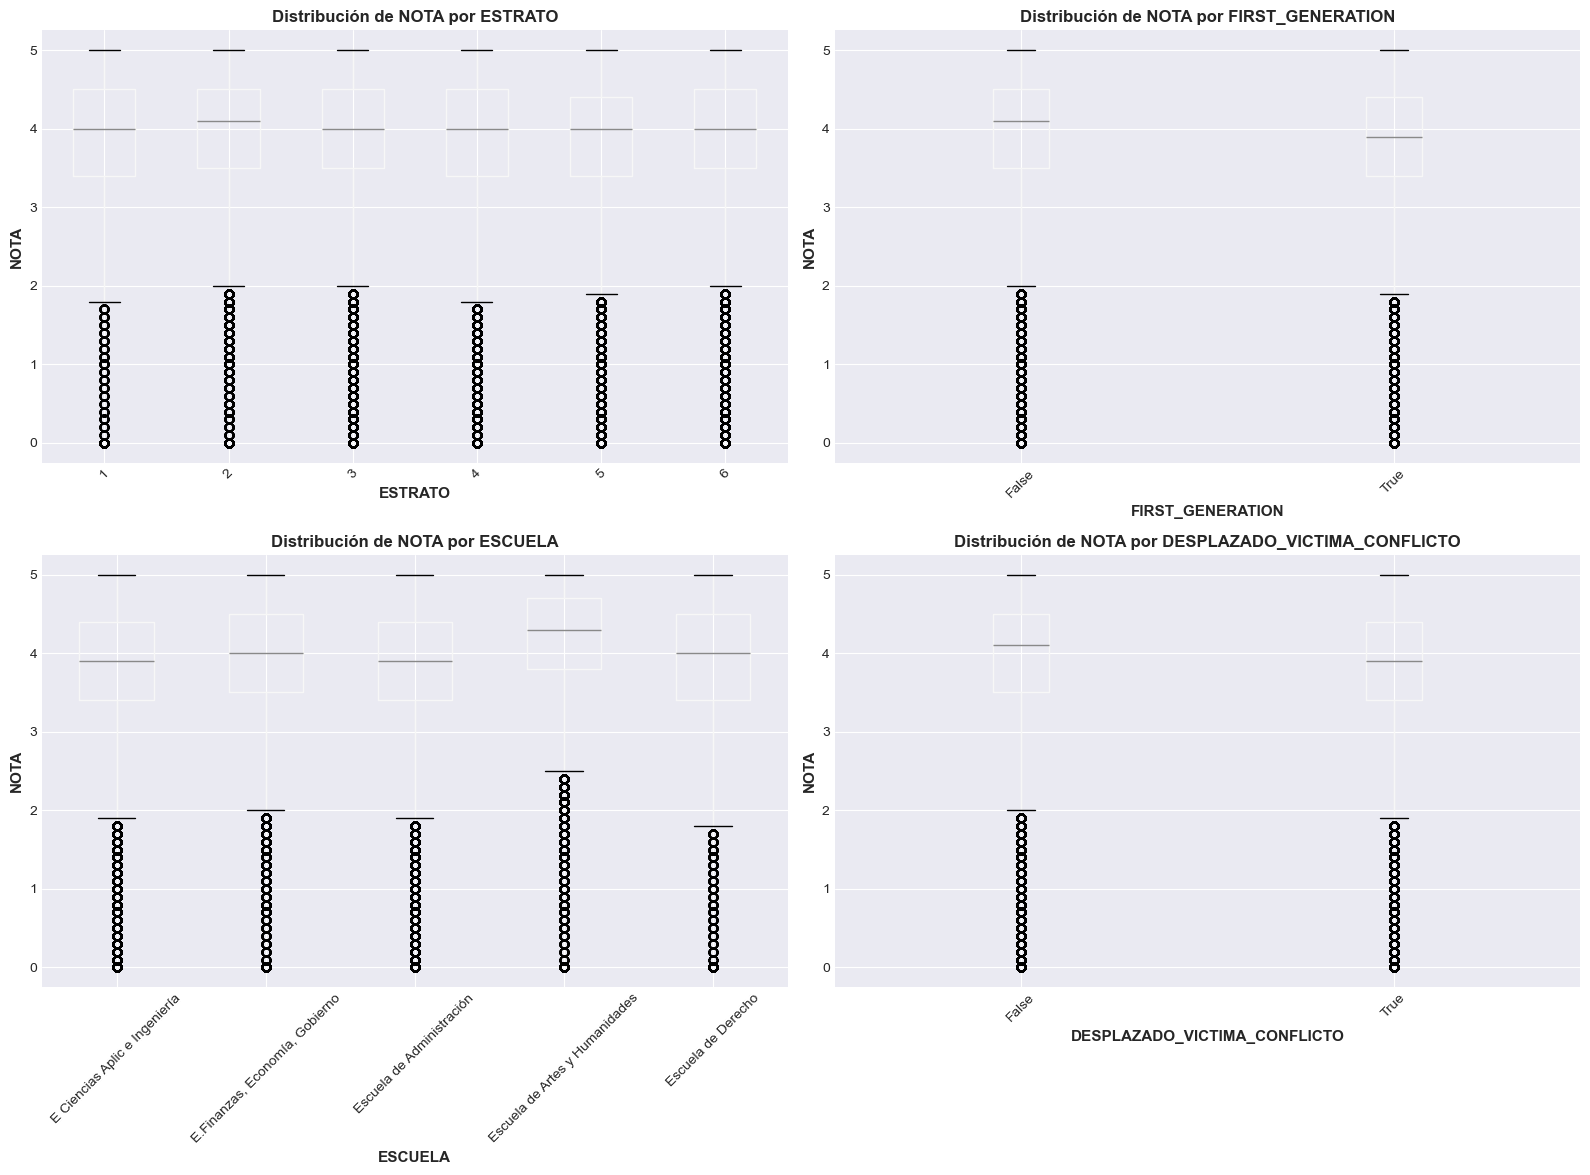


--------------------------------------------------------------------------------
4. RELACIÓN ENTRE VARIABLES DEMOGRÁFICAS Y ESTADO DEL ESTUDIANTE
--------------------------------------------------------------------------------

--- Tasa de Deserción por ESTRATO ---
         Desertores  Total_Estudiantes  Tasa_Desercion_%
ESTRATO                                                 
1               339               1005             33.73
2              1019               3534             28.83
4              2047               7235             28.29
3              2062               7513             27.45
5              2284               9699             23.55
6              2213               9411             23.52

--- Tasa de Deserción por FIRST_GENERATION ---
                  Desertores  Total_Estudiantes  Tasa_Desercion_%
FIRST_GENERATION                                                 
False                   5444              22158             24.57
True                   14100   

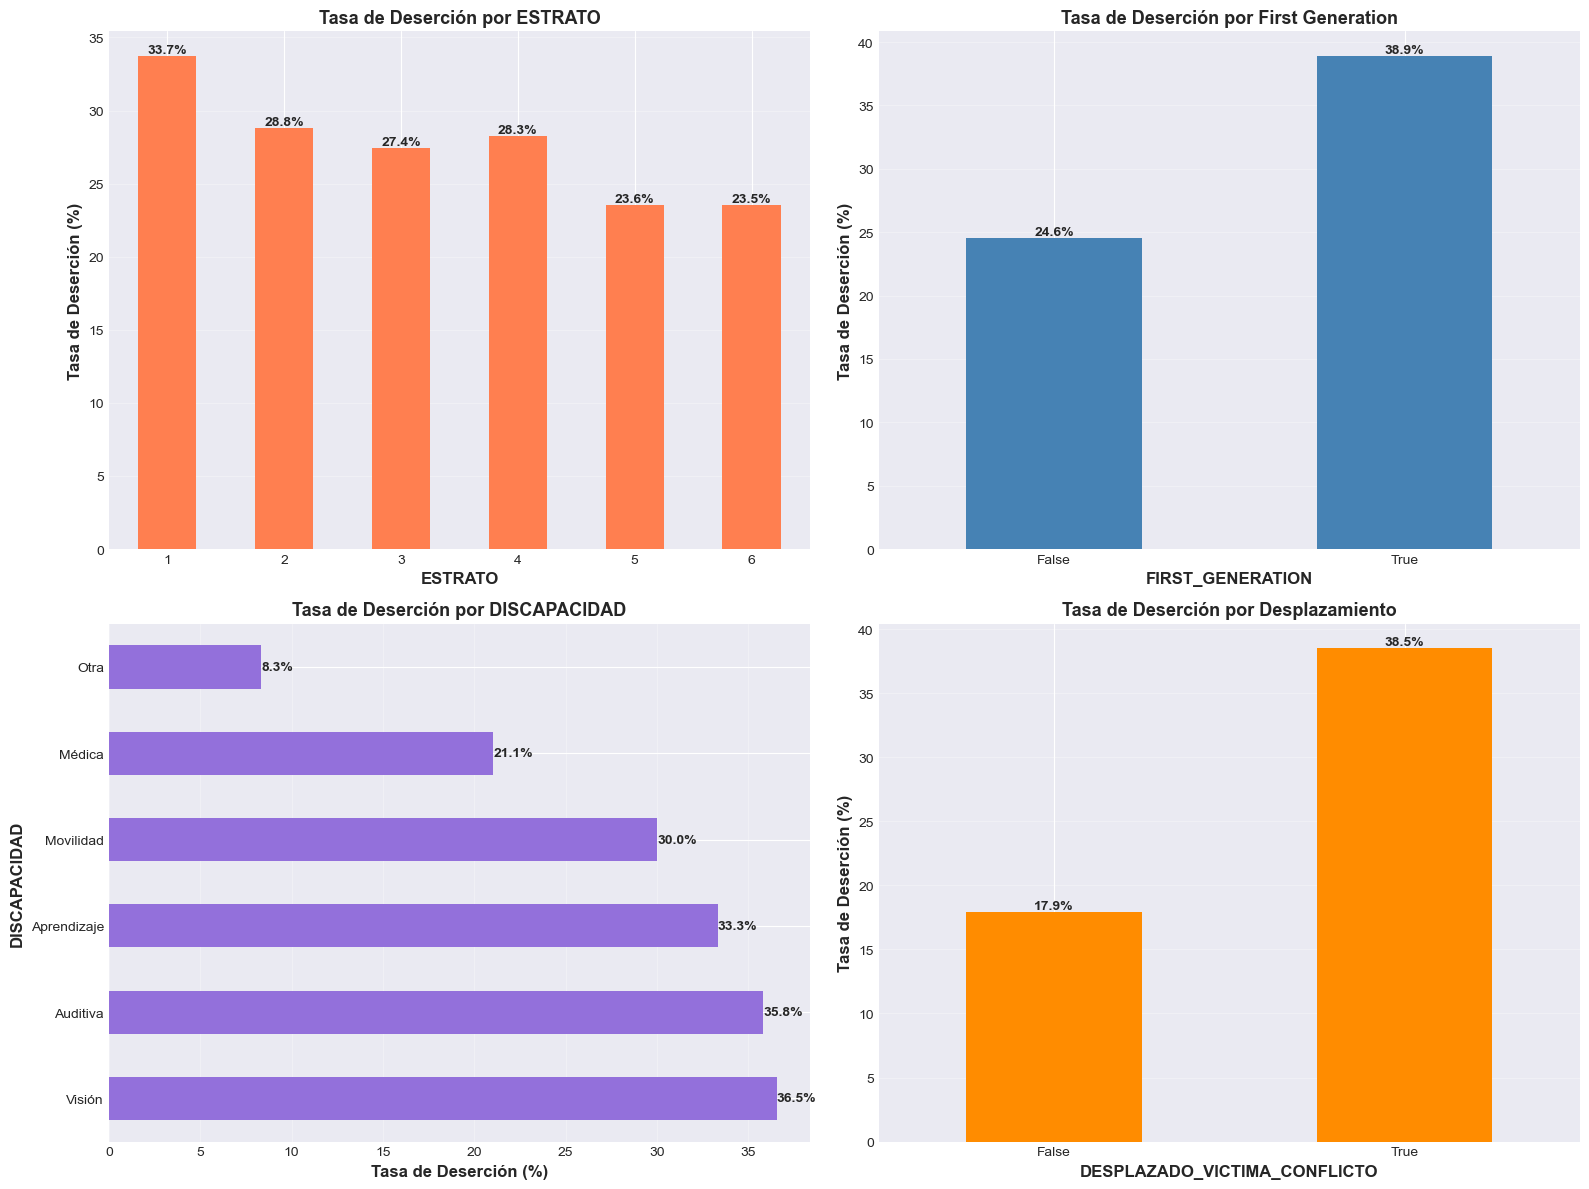


RESUMEN DE HALLAZGOS CLAVE

    CORRELACIONES NUMÉRICAS:
    • Se encontraron 11 correlaciones fuertes (|r| > 0.3)
    
    VARIABLES CATEGÓRICAS SIGNIFICATIVAS:
    • Variables con impacto significativo en NOTA (p < 0.05): 4
    
    FACTORES DE RIESGO DE DESERCIÓN:
    • Estrato con mayor deserción: 1
    • First Generation con mayor deserción: True
    


In [56]:
analizar_correlaciones(notas)

# 11. RESUMEN EJECUTIVO

In [59]:
def generar_resumen_ejecutivo(df):
    """
    Genera un resumen ejecutivo con los hallazgos principales
    """
    print("\n" + "="*80)
    print("RESUMEN EJECUTIVO")
    print("="*80)
    
    estudiantes_unicos = df['EMPLID_ANÓNIMO'].nunique()
    
    print(f"""
    INDICADORES CLAVE:
    ------------------
    • Total de registros: {len(df):,}
    • Estudiantes únicos: {estudiantes_unicos:,}
    • Materias únicas: {df['ID_MATERIA'].nunique():,}
    • Programas académicos: {df['NOMBRE_PROGRAMA'].nunique()}
    • Escuelas: {df['ESCUELA'].nunique()}
    • Rango temporal: {df['SEMESTRE'].min()} - {df['SEMESTRE'].max()}
    
    RENDIMIENTO ACADÉMICO:
    ----------------------
    • Nota promedio general: {df['NOTA'].mean():.2f}
    • Mediana de notas: {df['NOTA'].median():.2f}
    • Desviación estándar: {df['NOTA'].std():.2f}
    • Tasa de aprobación: {((df['NOTA'] >= 3.0).sum() / len(df) * 100):.2f}%
    
    ESCUELA CON MEJOR RENDIMIENTO:
    ------------------------------
    {df.groupby('ESCUELA')['NOTA'].mean().idxmax()}: {df.groupby('ESCUELA')['NOTA'].mean().max():.2f}
    
    ESCUELA CON MAYOR MATRÍCULA:
    ----------------------------
    {df['ESCUELA'].value_counts().idxmax()}: {df['ESCUELA'].value_counts().max():,} registros
    """)
    
    if 'DESERTOR' in df.columns:
        tasa_desercion = df.groupby('EMPLID_ANÓNIMO')['DESERTOR'].first().mean() * 100
        print(f"""
    INDICADORES DE PERMANENCIA ESTUDIANTIL:
    -------------------------
    • Tasa de deserción: {tasa_desercion:.2f}%
    • Tasa de graduación: {df.groupby('EMPLID_ANÓNIMO')['GRADUADO'].first().mean() * 100:.2f}%
    • Estudiantes activos: {df.groupby('EMPLID_ANÓNIMO')['ACTIVO'].first().mean() * 100:.2f}%
        """)

In [60]:
generar_resumen_ejecutivo(notas)


RESUMEN EJECUTIVO

    INDICADORES CLAVE:
    ------------------
    • Total de registros: 2,194,612
    • Estudiantes únicos: 58,406
    • Materias únicas: 7,679
    • Programas académicos: 32
    • Escuelas: 5
    • Rango temporal: 2000-1 - 2025-2
    
    RENDIMIENTO ACADÉMICO:
    ----------------------
    • Nota promedio general: 3.86
    • Mediana de notas: 4.00
    • Desviación estándar: 0.82
    • Tasa de aprobación: 92.57%
    
    ESCUELA CON MEJOR RENDIMIENTO:
    ------------------------------
    Escuela de Artes y Humanidades: 4.15
    
    ESCUELA CON MAYOR MATRÍCULA:
    ----------------------------
    Escuela de Administración: 933,521 registros
    

    INDICADORES DE PERMANENCIA ESTUDIANTIL:
    -------------------------
    • Tasa de deserción: 33.46%
    • Tasa de graduación: 52.06%
    • Estudiantes activos: 15.47%
        
